In [46]:
import pandas as pd

In [47]:
!pip install python-calamine

In [48]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\Anish kumar tiwari\Downloads\telcom_data (2).xlsx",
    engine="calamine"
)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

Dataset Loaded Successfully
Shape: (150001, 55)


In [49]:
top_10_handsets = df["Handset Type"].value_counts().head(10)
top_10_handsets

Handset Type
Huawei B528S-23A                19752
Apple iPhone 6S (A1688)          9419
Apple iPhone 6 (A1586)           9023
undefined                        8987
Apple iPhone 7 (A1778)           6326
Apple iPhone Se (A1723)          5187
Apple iPhone 8 (A1905)           4993
Apple iPhone Xr (A2105)          4568
Samsung Galaxy S8 (Sm-G950F)     4520
Apple iPhone X (A1901)           3813
Name: count, dtype: int64

In [50]:
top_10_handsets = top_10_handsets.reset_index()
top_10_handsets.columns = ["Handset Type", "Count"]
top_10_handsets

,Handset Type,Count
0,Huawei B528S-23A,19752
1,Apple iPhone 6S (A1688),9419
2,Apple iPhone 6 (A1586),9023
3,undefined,8987
4,Apple iPhone 7 (A1778),6326
5,Apple iPhone Se (A1723),5187
6,Apple iPhone 8 (A1905),4993
7,Apple iPhone Xr (A2105),4568
8,Samsung Galaxy S8 (Sm-G950F),4520
9,Apple iPhone X (A1901),3813


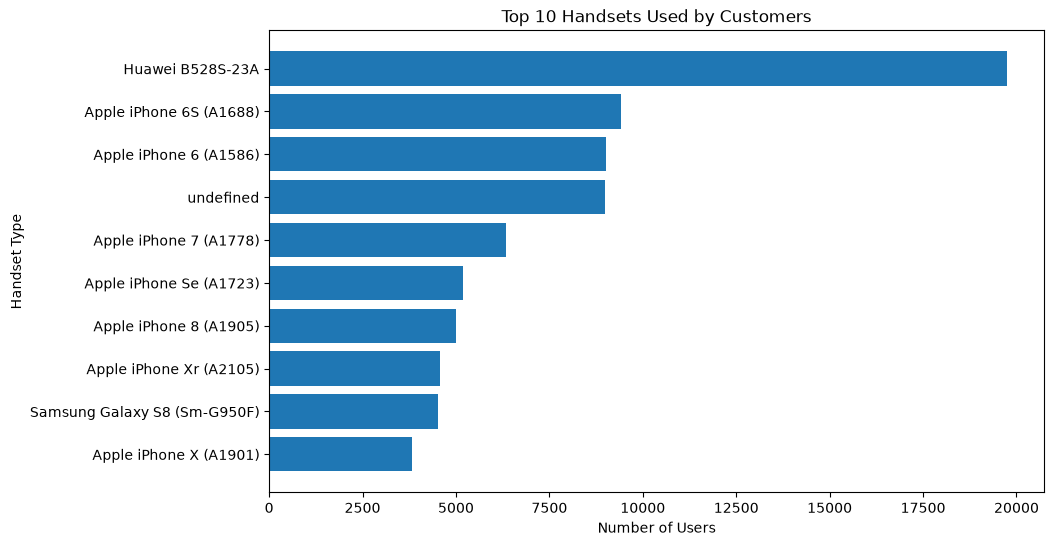

In [51]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(
    top_10_handsets["Handset Type"][::-1],
    top_10_handsets["Count"][::-1]
)
plt.xlabel("Number of Users")
plt.ylabel("Handset Type")
plt.title("Top 10 Handsets Used by Customers")
plt.show()

In [52]:
top_3_manufacturers = df["Handset Manufacturer"].value_counts().head(3)
top_3_manufacturers

Handset Manufacturer
Apple      59565
Samsung    40839
Huawei     34423
Name: count, dtype: int64

In [53]:
top_3_manufacturers = top_3_manufacturers.reset_index()
top_3_manufacturers.columns = ["Handset Manufacturer", "Count"]
top_3_manufacturers

,Handset Manufacturer,Count
0,Apple,59565
1,Samsung,40839
2,Huawei,34423


In [54]:
top_3_manufacturers_list = top_3_manufacturers["Handset Manufacturer"].tolist()
for manufacturer in top_3_manufacturers_list:
    print("\nTop 5 Handsets for", manufacturer)
    
    top_5 = (
        df[df["Handset Manufacturer"] == manufacturer]["Handset Type"]
        .value_counts()
        .head(5)
    )
    
    print(top_5)


Top 5 Handsets for Apple
Handset Type
Apple iPhone 6S (A1688)    9419
Apple iPhone 6 (A1586)     9023
Apple iPhone 7 (A1778)     6326
Apple iPhone Se (A1723)    5187
Apple iPhone 8 (A1905)     4993
Name: count, dtype: int64

Top 5 Handsets for Samsung
Handset Type
Samsung Galaxy S8 (Sm-G950F)    4520
Samsung Galaxy A5 Sm-A520F      3724
Samsung Galaxy J5 (Sm-J530)     3696
Samsung Galaxy J3 (Sm-J330)     3484
Samsung Galaxy S7 (Sm-G930X)    3199
Name: count, dtype: int64

Top 5 Handsets for Huawei
Handset Type
Huawei B528S-23A                  19752
Huawei E5180                       2079
Huawei P20 Lite Huawei Nova 3E     2021
Huawei P20                         1480
Huawei Y6 2018                      997
Name: count, dtype: int64


In [55]:
df.columns.tolist()

['Bearer Id',
 'Start',
 'Start ms',
 'End',
 'End ms',
 'Dur. (ms)',
 'IMSI',
 'MSISDN/Number',
 'IMEI',
 'Last Location Name',
 'Avg RTT DL (ms)',
 'Avg RTT UL (ms)',
 'Avg Bearer TP DL (kbps)',
 'Avg Bearer TP UL (kbps)',
 'TCP DL Retrans. Vol (Bytes)',
 'TCP UL Retrans. Vol (Bytes)',
 'DL TP < 50 Kbps (%)',
 '50 Kbps < DL TP < 250 Kbps (%)',
 '250 Kbps < DL TP < 1 Mbps (%)',
 'DL TP > 1 Mbps (%)',
 'UL TP < 10 Kbps (%)',
 '10 Kbps < UL TP < 50 Kbps (%)',
 '50 Kbps < UL TP < 300 Kbps (%)',
 'UL TP > 300 Kbps (%)',
 'HTTP DL (Bytes)',
 'HTTP UL (Bytes)',
 'Activity Duration DL (ms)',
 'Activity Duration UL (ms)',
 'Dur. (ms).1',
 'Handset Manufacturer',
 'Handset Type',
 'Nb of sec with 125000B < Vol DL',
 'Nb of sec with 1250B < Vol UL < 6250B',
 'Nb of sec with 31250B < Vol DL < 125000B',
 'Nb of sec with 37500B < Vol UL',
 'Nb of sec with 6250B < Vol DL < 31250B',
 'Nb of sec with 6250B < Vol UL < 37500B',
 'Nb of sec with Vol DL < 6250B',
 'Nb of sec with Vol UL < 1250B',
 'Socia

In [56]:
session_frequency = (
    df.groupby("MSISDN/Number")["Bearer Id"]
    .count()
    .reset_index()
)
session_frequency.columns = ["MSISDN/Number", "Number of xDR Sessions"]
session_frequency.head(10)

,MSISDN/Number,Number of xDR Sessions
0,3.360100e+10,1
1,3.360100e+10,1
2,3.360100e+10,1
3,3.360101e+10,1
4,3.360101e+10,2
5,3.360101e+10,2
6,3.360101e+10,2
7,3.360101e+10,1
8,3.360101e+10,2
9,3.360102e+10,1


In [57]:
session_duration = (
    df.groupby("MSISDN/Number")["Dur. (ms)"]
    .sum()
    .reset_index()
)
session_duration.columns = [
    "MSISDN/Number",
    "Total Session Duration (ms)"
]
session_duration.head(10)

,MSISDN/Number,Total Session Duration (ms)
0,3.360100e+10,116720.0
1,3.360100e+10,181230.0
2,3.360100e+10,134969.0
3,3.360101e+10,49878.0
4,3.360101e+10,37104.0
5,3.360101e+10,253983.0
6,3.360101e+10,128360.0
7,3.360101e+10,86399.0
8,3.360101e+10,495702.0
9,3.360102e+10,124854.0


In [58]:
[c for c in df.columns if "DL" in c or "UL" in c]

['Avg RTT DL (ms)',
 'Avg RTT UL (ms)',
 'Avg Bearer TP DL (kbps)',
 'Avg Bearer TP UL (kbps)',
 'TCP DL Retrans. Vol (Bytes)',
 'TCP UL Retrans. Vol (Bytes)',
 'DL TP < 50 Kbps (%)',
 '50 Kbps < DL TP < 250 Kbps (%)',
 '250 Kbps < DL TP < 1 Mbps (%)',
 'DL TP > 1 Mbps (%)',
 'UL TP < 10 Kbps (%)',
 '10 Kbps < UL TP < 50 Kbps (%)',
 '50 Kbps < UL TP < 300 Kbps (%)',
 'UL TP > 300 Kbps (%)',
 'HTTP DL (Bytes)',
 'HTTP UL (Bytes)',
 'Activity Duration DL (ms)',
 'Activity Duration UL (ms)',
 'Nb of sec with 125000B < Vol DL',
 'Nb of sec with 1250B < Vol UL < 6250B',
 'Nb of sec with 31250B < Vol DL < 125000B',
 'Nb of sec with 37500B < Vol UL',
 'Nb of sec with 6250B < Vol DL < 31250B',
 'Nb of sec with 6250B < Vol UL < 37500B',
 'Nb of sec with Vol DL < 6250B',
 'Nb of sec with Vol UL < 1250B',
 'Social Media DL (Bytes)',
 'Social Media UL (Bytes)',
 'Google DL (Bytes)',
 'Google UL (Bytes)',
 'Email DL (Bytes)',
 'Email UL (Bytes)',
 'Youtube DL (Bytes)',
 'Youtube UL (Bytes)',
 'Netf

In [59]:
user_traffic = (
    df.groupby("MSISDN/Number")[["Total DL (Bytes)", "Total UL (Bytes)"]]
    .sum()
    .reset_index()
)
user_traffic.columns = [
    "MSISDN/Number",
    "Total DL (Bytes)",
    "Total UL (Bytes)"
]
user_traffic.head(10)

,MSISDN/Number,Total DL (Bytes),Total UL (Bytes)
0,3.360100e+10,8.426375e+08,36053108.0
1,3.360100e+10,1.207552e+08,36104459.0
2,3.360100e+10,5.566597e+08,39306820.0
3,3.360101e+10,4.019932e+08,20327526.0
4,3.360101e+10,1.363130e+09,94280527.0
5,3.360101e+10,5.552080e+08,60009249.0
6,3.360101e+10,5.530412e+08,101681858.0
7,3.360101e+10,2.940851e+08,38575279.0
8,3.360101e+10,8.965602e+08,93572016.0
9,3.360102e+10,6.853728e+08,47091008.0


In [60]:
application_columns = [
    "Social Media DL (Bytes)", "Social Media UL (Bytes)",
    "Google DL (Bytes)", "Google UL (Bytes)",
    "Email DL (Bytes)", "Email UL (Bytes)",
    "Youtube DL (Bytes)", "Youtube UL (Bytes)",
    "Netflix DL (Bytes)", "Netflix UL (Bytes)",
    "Gaming DL (Bytes)", "Gaming UL (Bytes)",
    "Other DL (Bytes)", "Other UL (Bytes)"
]

user_application_data = (
    df.groupby("MSISDN/Number")[application_columns]
    .sum()
    .reset_index()
)

user_application_data.head(10)

,MSISDN/Number,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes)
0,3.360100e+10,2206504.0,25631.0,3337123.0,1051882.0,837400.0,493962.0,14900201.0,6724347.0,10265105.0,16915876.0,8.110911e+08,1367528.0,3.770970e+08,9473882.0
1,3.360100e+10,2598548.0,62017.0,4197697.0,1137166.0,2828821.0,478960.0,5324251.0,7107972.0,770569.0,10451194.0,1.050353e+08,14714780.0,2.795577e+08,2152370.0
2,3.360100e+10,3148004.0,47619.0,3343483.0,99643.0,2436500.0,768880.0,2137272.0,19196298.0,16525919.0,2827981.0,5.290685e+08,9759228.0,4.950865e+08,6607171.0
3,3.360101e+10,251469.0,28825.0,5937765.0,3740728.0,2178618.0,106052.0,4393123.0,2584198.0,1157362.0,784730.0,3.880748e+08,3051292.0,2.524800e+07,10031701.0
4,3.360101e+10,2861230.0,51312.0,13728668.0,4770948.0,2247808.0,1057661.0,10339971.0,31193031.0,24971647.0,24230077.0,1.308981e+09,5816727.0,7.776437e+08,27160771.0
5,3.360101e+10,3787122.0,5790.0,11993496.0,3269638.0,6513834.0,1334762.0,12169742.0,22177380.0,14569029.0,15746472.0,5.061747e+08,5461038.0,4.803586e+08,12014169.0
6,3.360101e+10,2707339.0,62288.0,4346088.0,5850315.0,736446.0,622513.0,2990819.0,23440516.0,12813052.0,32999345.0,5.294475e+08,19013593.0,2.051954e+08,19693288.0
7,3.360101e+10,1740000.0,42692.0,11036391.0,987223.0,1280558.0,935005.0,5100103.0,13792637.0,1392985.0,13899855.0,2.735350e+08,8829356.0,1.781130e+08,88511.0
8,3.360101e+10,5206619.0,82066.0,11046222.0,3087989.0,3666031.0,933794.0,41189830.0,22253972.0,27418209.0,26797908.0,8.080333e+08,25054690.0,1.026521e+09,15361597.0
9,3.360102e+10,938582.0,18193.0,11098762.0,1836407.0,1986925.0,796355.0,13624376.0,14945336.0,22460852.0,13064219.0,6.352633e+08,11832418.0,1.337412e+08,4598080.0


In [61]:
user_application_total = user_application_data[["MSISDN/Number"]].copy()
user_application_total["Social Media Data (Bytes)"] = (
    user_application_data["Social Media DL (Bytes)"] +
    user_application_data["Social Media UL (Bytes)"]
)
user_application_total["Google Data (Bytes)"] = (
    user_application_data["Google DL (Bytes)"] +
    user_application_data["Google UL (Bytes)"]
)
user_application_total["Email Data (Bytes)"] = (
    user_application_data["Email DL (Bytes)"] +
    user_application_data["Email UL (Bytes)"]
)
user_application_total["Youtube Data (Bytes)"] = (
    user_application_data["Youtube DL (Bytes)"] +
    user_application_data["Youtube UL (Bytes)"]
)
user_application_total["Netflix Data (Bytes)"] = (
    user_application_data["Netflix DL (Bytes)"] +
    user_application_data["Netflix UL (Bytes)"]
)
user_application_total["Gaming Data (Bytes)"] = (
    user_application_data["Gaming DL (Bytes)"] +
    user_application_data["Gaming UL (Bytes)"]
)
user_application_total["Other Data (Bytes)"] = (
    user_application_data["Other DL (Bytes)"] +
    user_application_data["Other UL (Bytes)"]
)
user_application_total.head(10)

,MSISDN/Number,Social Media Data (Bytes),Google Data (Bytes),Email Data (Bytes),Youtube Data (Bytes),Netflix Data (Bytes),Gaming Data (Bytes),Other Data (Bytes)
0,3.360100e+10,2232135.0,4389005.0,1331362.0,21624548.0,27180981.0,8.124587e+08,3.865709e+08
1,3.360100e+10,2660565.0,5334863.0,3307781.0,12432223.0,11221763.0,1.197501e+08,2.817101e+08
2,3.360100e+10,3195623.0,3443126.0,3205380.0,21333570.0,19353900.0,5.388277e+08,5.016937e+08
3,3.360101e+10,280294.0,9678493.0,2284670.0,6977321.0,1942092.0,3.911261e+08,3.527970e+07
4,3.360101e+10,2912542.0,18499616.0,3305469.0,41533002.0,49201724.0,1.314798e+09,8.048045e+08
5,3.360101e+10,3792912.0,15263134.0,7848596.0,34347122.0,30315501.0,5.116358e+08,4.923728e+08
6,3.360101e+10,2769627.0,10196403.0,1358959.0,26431335.0,45812397.0,5.484611e+08,2.248887e+08
7,3.360101e+10,1782692.0,12023614.0,2215563.0,18892740.0,15292840.0,2.823644e+08,1.782015e+08
8,3.360101e+10,5288685.0,14134211.0,4599825.0,63443802.0,54216117.0,8.330880e+08,1.041883e+09
9,3.360102e+10,956775.0,12935169.0,2783280.0,28569712.0,35525071.0,6.470957e+08,1.383392e+08


In [62]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Start                                            1
Start ms                                         1
End                                              1
End ms                                           1
Dur. (ms)                                        1
IMSI                                           570
MSISDN/Number                                 1066
IMEI                                           572
Last Location Name                            1153
Avg RTT DL (ms)                              27829
Avg RTT UL (ms)                              27812
Avg Bearer TP DL (kbps)                          1
Avg Bearer TP UL (kbps)                          1
TCP DL Retrans. Vol (Bytes)                  88146
TCP UL Retrans. Vol (Bytes)                  96649
DL TP < 50 Kbps (%)                            754
50 Kbps < DL TP < 250 Kbps (%)                 754
250 Kbps < DL TP < 1 Mbps (%)                  754
DL TP > 1 Mbps (%)                             754
UL TP < 10 Kbps (%)            

In [63]:
numeric_columns = df.select_dtypes(include="number").columns
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].mean())

In [64]:
df.isnull().sum()[df.isnull().sum() > 0]

Start                      1
End                        1
Last Location Name      1153
Handset Manufacturer     572
Handset Type             572
dtype: int64

In [65]:
df[[
    "Start",
    "End",
    "Last Location Name",
    "Handset Manufacturer",
    "Handset Type"
]].dtypes

Start                   datetime64[us]
End                     datetime64[us]
Last Location Name              object
Handset Manufacturer               str
Handset Type                       str
dtype: object

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype         
---  ------                                    --------------   -----         
 0   Bearer Id                                 150001 non-null  object        
 1   Start                                     150000 non-null  datetime64[us]
 2   Start ms                                  150001 non-null  float64       
 3   End                                       150000 non-null  datetime64[us]
 4   End ms                                    150001 non-null  float64       
 5   Dur. (ms)                                 150001 non-null  float64       
 6   IMSI                                      150001 non-null  float64       
 7   MSISDN/Number                             150001 non-null  float64       
 8   IMEI                                      150001 non-null  float64       
 9   Last Location Name        

In [67]:
df.describe()

,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Avg RTT DL (ms),Avg RTT UL (ms),...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,150000,150001.000000,150000,150001.000000,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,150001.000000,150001.000000,...,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05
mean,2019-04-26 12:36:38.953740,499.188200,2019-04-27 17:40:08.059673,498.800880,1.046086e+05,2.082016e+14,4.188282e+10,4.847455e+13,109.795706,17.662883,...,1.163407e+07,1.100941e+07,1.162685e+07,1.100175e+07,4.220447e+08,8.288398e+06,4.211005e+08,8.264799e+06,4.112121e+07,4.546434e+08
min,2019-04-04 12:01:18,0.000000,2019-04-24 22:59:58,0.000000,7.142000e+03,2.040471e+14,3.360100e+10,4.400152e+11,0.000000,0.000000,...,5.300000e+01,1.050000e+02,4.200000e+01,3.500000e+01,2.516000e+03,5.900000e+01,3.290000e+03,1.480000e+02,2.866892e+06,7.114041e+06
25%,2019-04-25 00:26:00.750000,250.000000,2019-04-26 07:30:11.500000,251.000000,5.744200e+04,2.082014e+14,3.365151e+10,3.546261e+13,35.000000,3.000000,...,5.833501e+06,5.517965e+06,5.777156e+06,5.475981e+06,2.104733e+08,4.128476e+06,2.101869e+08,4.145943e+06,3.322203e+07,2.431072e+08
50%,2019-04-26 08:51:24.500000,499.000000,2019-04-27 23:02:05,500.000000,8.639900e+04,2.082015e+14,3.366380e+10,3.572241e+13,54.000000,7.000000,...,1.161602e+07,1.101345e+07,1.164222e+07,1.099638e+07,4.234081e+08,8.291208e+06,4.218030e+08,8.267071e+06,4.114324e+07,4.558409e+08
75%,2019-04-27 18:18:59.750000,749.000000,2019-04-29 07:15:07.500000,750.000000,1.324300e+05,2.082018e+14,3.368473e+10,8.611970e+13,109.795706,17.662883,...,1.744852e+07,1.651556e+07,1.747048e+07,1.650727e+07,6.331742e+08,1.243162e+07,6.316918e+08,1.238415e+07,4.903424e+07,6.657051e+08
max,2019-04-29 07:28:43,999.000000,2019-04-30 23:59:27,999.000000,1.859336e+06,2.140743e+14,8.823971e+14,9.900120e+13,96923.000000,7120.000000,...,2.325910e+07,2.201196e+07,2.325919e+07,2.201196e+07,8.434419e+08,1.655879e+07,8.434425e+08,1.655882e+07,7.833131e+07,9.029696e+08
std,NaN,288.610872,NaN,288.096693,8.103735e+04,2.144722e+10,2.438731e+12,2.237359e+13,559.342620,76.529933,...,6.710569e+06,6.345423e+06,6.725218e+06,6.359490e+06,2.439675e+08,4.782700e+06,2.432050e+08,4.769004e+06,1.127635e+07,2.441421e+08


In [68]:
numeric_df = df.select_dtypes(include="number")
dispersion = pd.DataFrame({
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Standard Deviation": numeric_df.std(),
    "Minimum": numeric_df.min(),
    "Maximum": numeric_df.max()
})
dispersion.head(20)

,Mean,Median,Standard Deviation,Minimum,Maximum
Start ms,4.991882e+02,4.990000e+02,2.886109e+02,0.000000e+00,9.990000e+02
End ms,4.988009e+02,5.000000e+02,2.880967e+02,0.000000e+00,9.990000e+02
Dur. (ms),1.046086e+05,8.639900e+04,8.103735e+04,7.142000e+03,1.859336e+06
IMSI,2.082016e+14,2.082015e+14,2.144722e+10,2.040471e+14,2.140743e+14
MSISDN/Number,4.188282e+10,3.366380e+10,2.438731e+12,3.360100e+10,8.823971e+14
IMEI,4.847455e+13,3.572241e+13,2.237359e+13,4.400152e+11,9.900120e+13
Avg RTT DL (ms),1.097957e+02,5.400000e+01,5.593426e+02,0.000000e+00,9.692300e+04
Avg RTT UL (ms),1.766288e+01,7.000000e+00,7.652993e+01,0.000000e+00,7.120000e+03
Avg Bearer TP DL (kbps),1.330005e+04,6.300000e+01,2.397180e+04,0.000000e+00,3.781600e+05
Avg Bearer TP UL (kbps),1.770429e+03,6.300000e+01,4.625340e+03,0.000000e+00,5.861300e+04


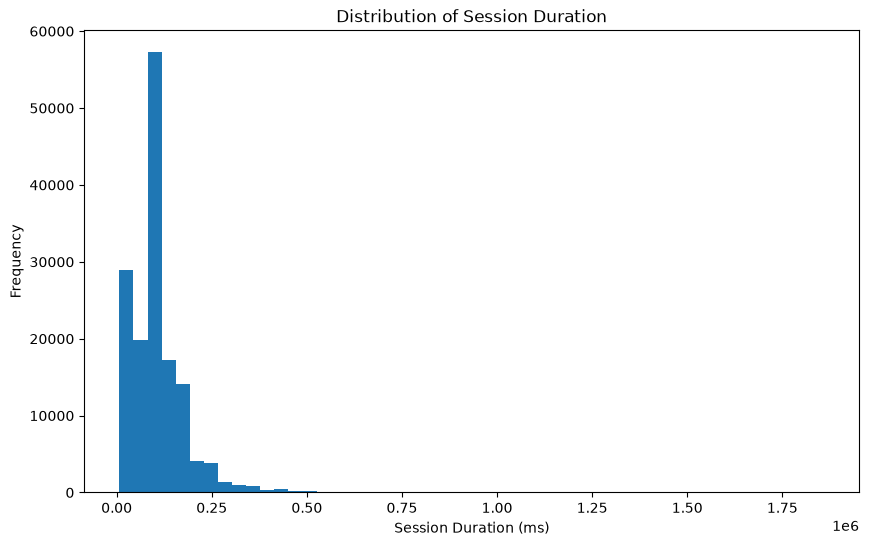

In [69]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df["Dur. (ms)"], bins=50)
plt.xlabel("Session Duration (ms)")
plt.ylabel("Frequency")
plt.title("Distribution of Session Duration")
plt.show()

In [70]:
df["Total Traffic (Bytes)"] = (
    df["Total DL (Bytes)"] + df["Total UL (Bytes)"]
)

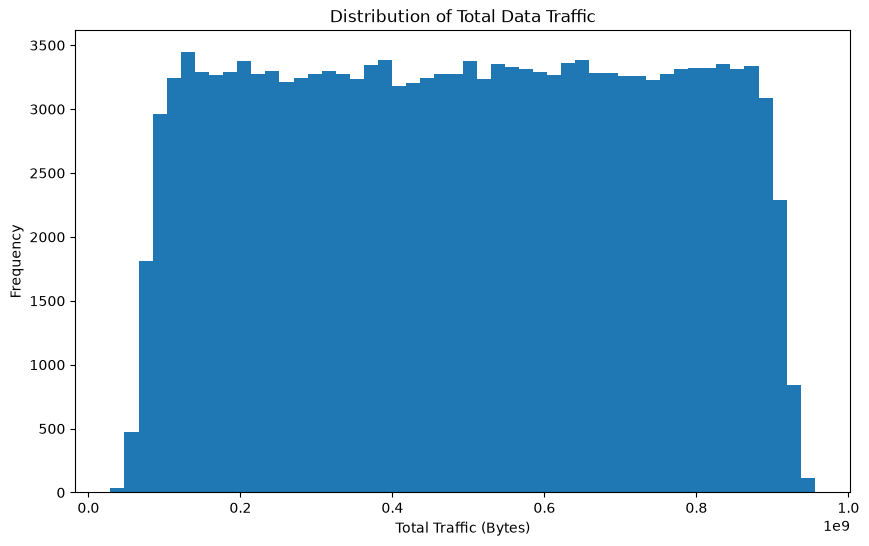

In [71]:
plt.figure(figsize=(10, 6))

plt.hist(df["Total Traffic (Bytes)"], bins=50)

plt.xlabel("Total Traffic (Bytes)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Data Traffic")

plt.show()

#Application Data Distribution

In [72]:
application_totals = {
    "Social Media": df["Social Media DL (Bytes)"] + df["Social Media UL (Bytes)"],
    "Google": df["Google DL (Bytes)"] + df["Google UL (Bytes)"],
    "Email": df["Email DL (Bytes)"] + df["Email UL (Bytes)"],
    "Youtube": df["Youtube DL (Bytes)"] + df["Youtube UL (Bytes)"],
    "Netflix": df["Netflix DL (Bytes)"] + df["Netflix UL (Bytes)"],
    "Gaming": df["Gaming DL (Bytes)"] + df["Gaming UL (Bytes)"],
    "Other": df["Other DL (Bytes)"] + df["Other UL (Bytes)"]
}
application_totals_df = pd.DataFrame(application_totals)
application_totals_df.head()

,Social Media,Google,Email,Youtube,Netflix,Gaming,Other
0,1570185.0,2905912.0,3701304.0,18355943.0,17855187.0,292426453.0,180558843.0
1,1933278.0,4414096.0,937385.0,39359124.0,35565545.0,609920783.0,541959383.0
2,1726277.0,10229119.0,3363124.0,34425237.0,23751202.0,229980251.0,414908351.0
3,657493.0,11811761.0,2070983.0,36534765.0,15092588.0,810387875.0,761837216.0
4,912788.0,7748843.0,2110349.0,34222253.0,17539799.0,531237049.0,564619822.0


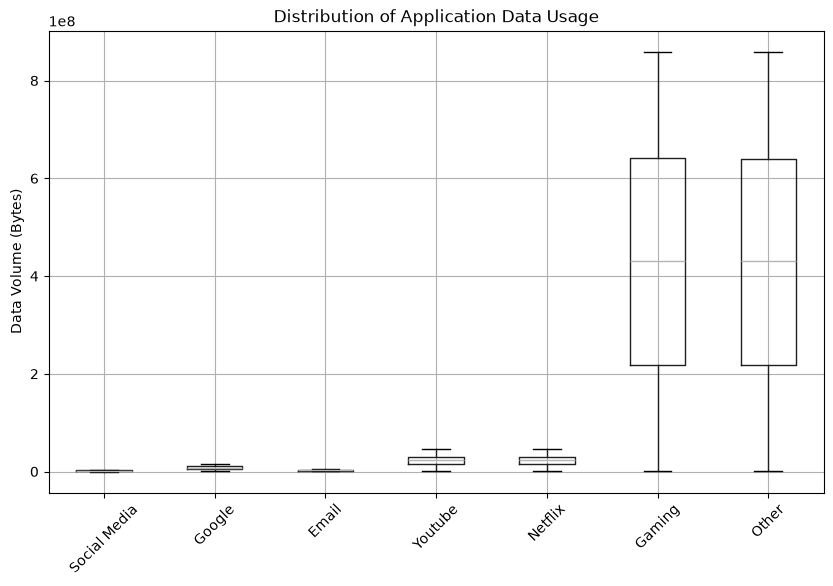

In [73]:
plt.figure(figsize=(10, 6))

application_totals_df.boxplot()

plt.ylabel("Data Volume (Bytes)")
plt.title("Distribution of Application Data Usage")

plt.xticks(rotation=45)

plt.show()

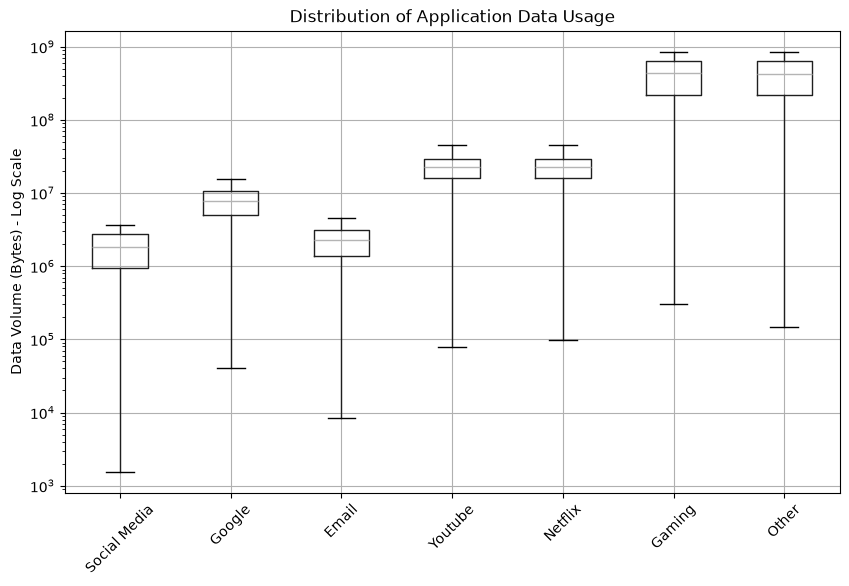

In [74]:
plt.figure(figsize=(10, 6))

application_totals_df.boxplot()

plt.yscale("log")

plt.ylabel("Data Volume (Bytes) - Log Scale")
plt.title("Distribution of Application Data Usage")

plt.xticks(rotation=45)

plt.show()

In [75]:
numeric_columns = df.select_dtypes(include="number").columns
outlier_summary = {}
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = ((df[column] < lower_limit) | (df[column] > upper_limit)).sum()
    
    outlier_summary[column] = outliers
outlier_summary = pd.Series(outlier_summary)
outlier_summary[outlier_summary > 0].sort_values(ascending=False)

Nb of sec with 6250B < Vol UL < 37500B      38158
10 Kbps < UL TP < 50 Kbps (%)               32791
250 Kbps < DL TP < 1 Mbps (%)               29751
Activity Duration DL (ms)                   26660
Activity Duration UL (ms)                   26022
MSISDN/Number                               24742
Nb of sec with Vol UL < 1250B               24545
Nb of sec with Vol DL < 6250B               23854
DL TP > 1 Mbps (%)                          22846
UL TP < 10 Kbps (%)                         22123
Avg Bearer TP UL (kbps)                     21531
Nb of sec with 37500B < Vol UL              19747
DL TP < 50 Kbps (%)                         18352
50 Kbps < DL TP < 250 Kbps (%)              15220
IMSI                                        13250
Avg Bearer TP DL (kbps)                     13235
Nb of sec with 6250B < Vol DL < 31250B      10799
Nb of sec with 31250B < Vol DL < 125000B     9173
Avg RTT UL (ms)                              8975
Nb of sec with 125000B < Vol DL              7760


In [76]:
numeric_columns = df.select_dtypes(include="number").columns
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    mean_value = df[column].mean()

    outlier_condition = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    )

    df.loc[outlier_condition, column] = mean_value

In [77]:
outlier_summary_after = {}

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ).sum()

    outlier_summary_after[column] = outliers

outlier_summary_after = pd.Series(outlier_summary_after)

outlier_summary_after[outlier_summary_after > 0]

Dur. (ms)                          4029
MSISDN/Number                     24762
Avg Bearer TP DL (kbps)           11326
DL TP < 50 Kbps (%)                5944
50 Kbps < DL TP < 250 Kbps (%)     7741
10 Kbps < UL TP < 50 Kbps (%)     32791
50 Kbps < UL TP < 300 Kbps (%)     5335
UL TP > 300 Kbps (%)               3249
Activity Duration DL (ms)         26660
Dur. (ms).1                        4029
Nb of sec with 37500B < Vol UL    19747
Total UL (Bytes)                     18
dtype: int64

In [78]:
df.isnull().sum()[df.isnull().sum() > 0]

Start                      1
End                        1
Last Location Name      1153
Handset Manufacturer     572
Handset Type             572
dtype: int64

In [79]:
variable_info = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Count": df.notnull().sum(),
    "Missing Values": df.isnull().sum()
})

variable_info

,Variable,Data Type,Non-Null Count,Missing Values
Bearer Id,Bearer Id,object,150001,0
Start,Start,datetime64[us],150000,1
Start ms,Start ms,float64,150001,0
End,End,datetime64[us],150000,1
End ms,End ms,float64,150001,0
Dur. (ms),Dur. (ms),float64,150001,0
IMSI,IMSI,float64,150001,0
MSISDN/Number,MSISDN/Number,float64,150001,0
IMEI,IMEI,float64,150001,0
Last Location Name,Last Location Name,object,148848,1153


In [80]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\Anish kumar tiwari\Downloads\telcom_data (2).xlsx",
    engine="calamine"
)

print("Dataset Reloaded")
print(df.shape)

Dataset Reloaded
(150001, 55)


In [81]:
exclude_columns = ["IMSI", "MSISDN/Number", "IMEI"]

numeric_columns = [
    col for col in df.select_dtypes(include="number").columns
    if col not in exclude_columns
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].mean())

In [82]:
df.isnull().sum()[df.isnull().sum() > 0]

Start                      1
End                        1
IMSI                     570
MSISDN/Number           1066
IMEI                     572
Last Location Name      1153
Handset Manufacturer     572
Handset Type             572
dtype: int64

In [83]:
df["Start"] = df["Start"].fillna(df["Start"].mean())
df["End"] = df["End"].fillna(df["End"].mean())
print("Datetime missing values treated successfully")

Datetime missing values treated successfully


In [84]:
df.isnull().sum()[df.isnull().sum() > 0]

IMSI                     570
MSISDN/Number           1066
IMEI                     572
Last Location Name      1153
Handset Manufacturer     572
Handset Type             572
dtype: int64

In [85]:
numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    mean_value = df[column].mean()

    outlier_condition = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    )

    df.loc[outlier_condition, column] = mean_value

print("Outliers treated successfully")

Outliers treated successfully


In [86]:
outlier_check = {}

numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ).sum()

    outlier_check[column] = outliers

outlier_check = pd.Series(outlier_check)

outlier_check[outlier_check > 0].sort_values(ascending=False)

10 Kbps < UL TP < 50 Kbps (%)     32791
Activity Duration DL (ms)         26660
MSISDN/Number                     24130
Nb of sec with 37500B < Vol UL    19747
Avg Bearer TP DL (kbps)           11326
50 Kbps < DL TP < 250 Kbps (%)     7741
DL TP < 50 Kbps (%)                5944
50 Kbps < UL TP < 300 Kbps (%)     5335
Dur. (ms)                          4029
Dur. (ms).1                        4029
UL TP > 300 Kbps (%)               3249
Total UL (Bytes)                     18
dtype: int64

In [87]:
numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:

    while True:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        outlier_condition = (
            (df[column] < lower_limit) |
            (df[column] > upper_limit)
        )

        if outlier_condition.sum() == 0:
            break

        mean_value = df[column].mean()
        df.loc[outlier_condition, column] = mean_value

print("All outliers treated successfully")

All outliers treated successfully


In [88]:
outlier_check = {}

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ).sum()

    outlier_check[column] = outliers

outlier_check = pd.Series(outlier_check)

outlier_check[outlier_check > 0]

Series([], dtype: int64)

In [89]:
df["Total Traffic (Bytes)"] = (
    df["Total DL (Bytes)"] + df["Total UL (Bytes)"]
)

df["Social Media Total (Bytes)"] = (
    df["Social Media DL (Bytes)"] + df["Social Media UL (Bytes)"]
)

df["Google Total (Bytes)"] = (
    df["Google DL (Bytes)"] + df["Google UL (Bytes)"]
)

df["Email Total (Bytes)"] = (
    df["Email DL (Bytes)"] + df["Email UL (Bytes)"]
)

df["Youtube Total (Bytes)"] = (
    df["Youtube DL (Bytes)"] + df["Youtube UL (Bytes)"]
)

df["Netflix Total (Bytes)"] = (
    df["Netflix DL (Bytes)"] + df["Netflix UL (Bytes)"]
)

df["Gaming Total (Bytes)"] = (
    df["Gaming DL (Bytes)"] + df["Gaming UL (Bytes)"]
)

df["Other Total (Bytes)"] = (
    df["Other DL (Bytes)"] + df["Other UL (Bytes)"]
)

print("Bivariate analysis variables created successfully")

Bivariate analysis variables created successfully


In [90]:
df[
    [
        "MSISDN/Number",
        "Total Traffic (Bytes)",
        "Social Media Total (Bytes)",
        "Google Total (Bytes)",
        "Email Total (Bytes)",
        "Youtube Total (Bytes)",
        "Netflix Total (Bytes)",
        "Gaming Total (Bytes)",
        "Other Total (Bytes)"
    ]
].head()

,MSISDN/Number,Total Traffic (Bytes),Social Media Total (Bytes),Google Total (Bytes),Email Total (Bytes),Youtube Total (Bytes),Netflix Total (Bytes),Gaming Total (Bytes),Other Total (Bytes)
0,3.366496e+10,345629377.0,1570185.0,2905912.0,3701304.0,18355943.0,17855187.0,292426453.0,180558843.0
1,3.368185e+10,707185356.0,1933278.0,4414096.0,937385.0,39359124.0,35565545.0,609920783.0,541959383.0
2,3.369280e+10,307690973.0,1726277.0,10229119.0,3363124.0,34425237.0,23751202.0,229980251.0,414908351.0
3,3.369280e+10,889352748.0,657493.0,11811761.0,2070983.0,36534765.0,15092588.0,810387875.0,761837216.0
4,3.369980e+10,607681403.0,912788.0,7748843.0,2110349.0,34222253.0,17539799.0,531237049.0,564619822.0


In [91]:
application_columns = [
    "Social Media Total (Bytes)",
    "Google Total (Bytes)",
    "Email Total (Bytes)",
    "Youtube Total (Bytes)",
    "Netflix Total (Bytes)",
    "Gaming Total (Bytes)",
    "Other Total (Bytes)"
]

correlation_with_total = df[
    application_columns + ["Total Traffic (Bytes)"]
].corr()["Total Traffic (Bytes)"].drop("Total Traffic (Bytes)")

correlation_with_total.sort_values(ascending=False)

Gaming Total (Bytes)          0.998265
Youtube Total (Bytes)         0.034655
Netflix Total (Bytes)         0.034539
Google Total (Bytes)          0.013296
Social Media Total (Bytes)    0.005379
Email Total (Bytes)           0.003777
Other Total (Bytes)          -0.002454
Name: Total Traffic (Bytes), dtype: float64

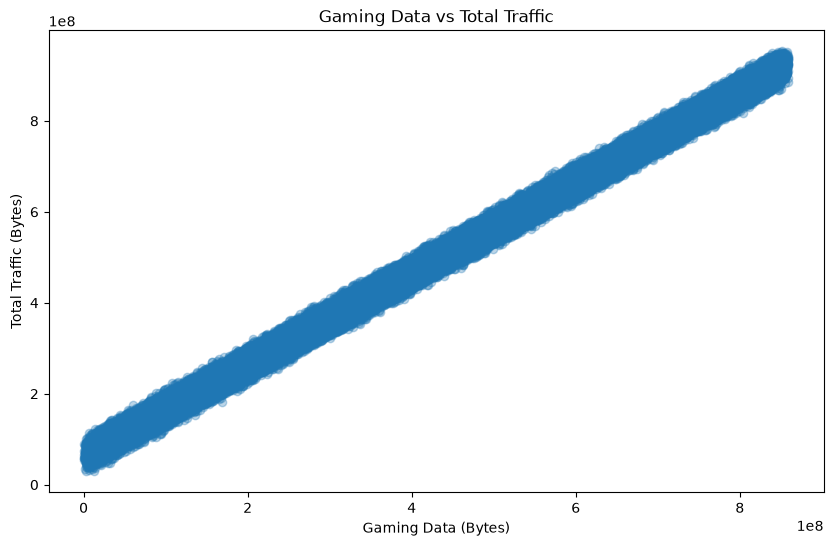

In [92]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Gaming Total (Bytes)"],
    df["Total Traffic (Bytes)"],
    alpha=0.3
)

plt.xlabel("Gaming Data (Bytes)")
plt.ylabel("Total Traffic (Bytes)")
plt.title("Gaming Data vs Total Traffic")

plt.show()

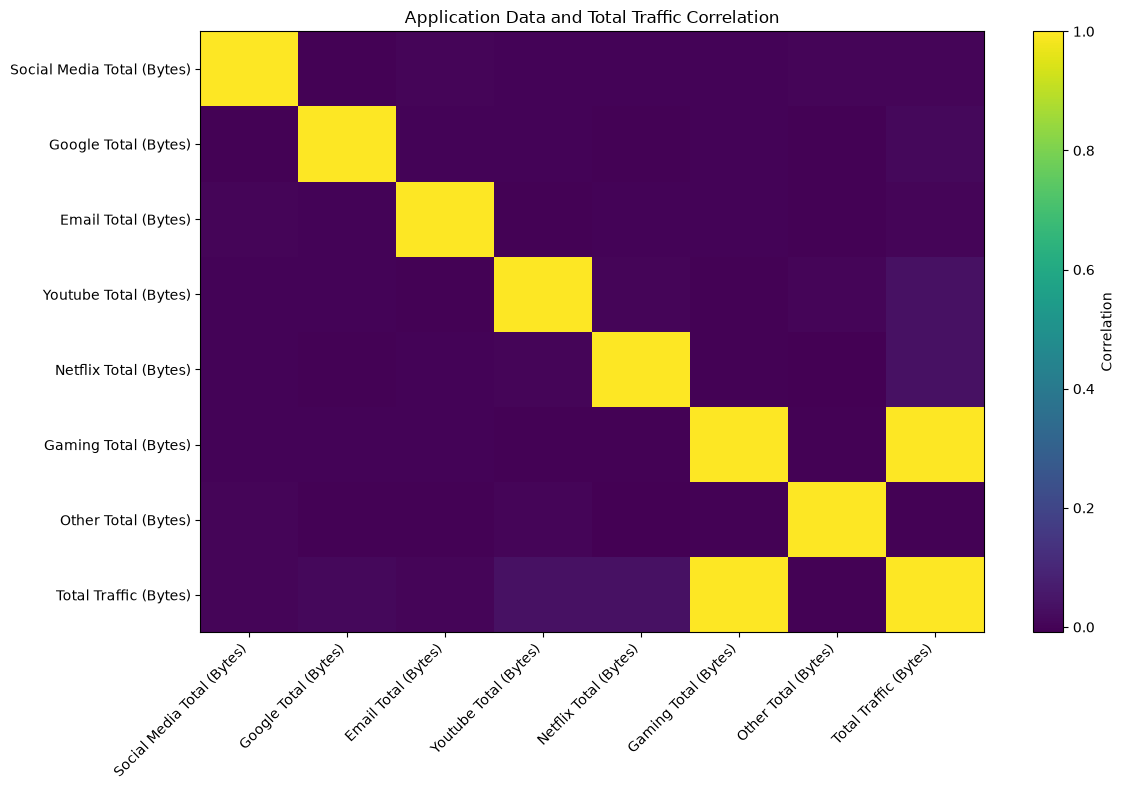

In [93]:
application_columns = [
    "Social Media Total (Bytes)",
    "Google Total (Bytes)",
    "Email Total (Bytes)",
    "Youtube Total (Bytes)",
    "Netflix Total (Bytes)",
    "Gaming Total (Bytes)",
    "Other Total (Bytes)",
    "Total Traffic (Bytes)"
]

correlation_matrix = df[application_columns].corr()

plt.figure(figsize=(12, 8))

plt.imshow(correlation_matrix, aspect="auto")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label="Correlation")

plt.title("Application Data and Total Traffic Correlation")

plt.tight_layout()
plt.show()

In [94]:
user_duration_traffic = df.groupby("MSISDN/Number").agg(
    Total_Duration=("Dur. (ms)", "sum"),
    Total_Traffic=("Total Traffic (Bytes)", "sum")
).reset_index()

user_duration_traffic.head()

,MSISDN/Number,Total_Duration,Total_Traffic
0,3.360301e+10,120325.000000,642463098.0
1,3.360301e+10,135718.000000,864013225.0
2,3.360301e+10,109906.000000,122304382.0
3,3.360301e+10,135968.000000,446771227.0
4,3.360301e+10,178817.574377,784493240.0


In [95]:
user_duration_traffic["Decile"] = pd.qcut(
    user_duration_traffic["Total_Duration"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

user_duration_traffic.head()

,MSISDN/Number,Total_Duration,Total_Traffic,Decile
0,3.360301e+10,120325.000000,642463098.0,7
1,3.360301e+10,135718.000000,864013225.0,7
2,3.360301e+10,109906.000000,122304382.0,7
3,3.360301e+10,135968.000000,446771227.0,7
4,3.360301e+10,178817.574377,784493240.0,9


In [96]:
top_five_deciles = user_duration_traffic[
    user_duration_traffic["Decile"] >= 6
]

decile_summary = top_five_deciles.groupby("Decile").agg(
    Total_Duration=("Total_Duration", "sum"),
    Total_Data=("Total_Traffic", "sum"),
    Number_of_Users=("MSISDN/Number", "count")
).reset_index()

decile_summary

,Decile,Total_Duration,Total_Data,Number_of_Users
0,6,8.887565e+08,4.840791e+12,8799
1,7,1.102357e+09,5.404498e+12,8971
2,8,1.374074e+09,5.289854e+12,8969
3,9,1.649827e+09,8.273227e+12,8970
4,10,4.980412e+09,2.566860e+13,8970


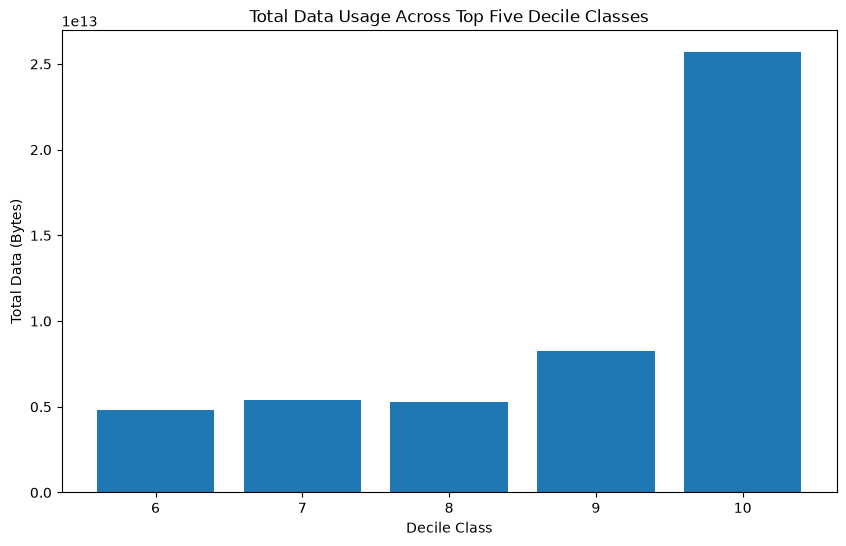

In [97]:
plt.figure(figsize=(10, 6))

plt.bar(
    decile_summary["Decile"].astype(str),
    decile_summary["Total_Data"]
)

plt.xlabel("Decile Class")
plt.ylabel("Total Data (Bytes)")
plt.title("Total Data Usage Across Top Five Decile Classes")

plt.show()

In [98]:
correlation_columns = [
    "Dur. (ms)",
    "Avg RTT DL (ms)",
    "Avg RTT UL (ms)",
    "Avg Bearer TP DL (kbps)",
    "Avg Bearer TP UL (kbps)",
    "Total DL (Bytes)",
    "Total UL (Bytes)",
    "Total Traffic (Bytes)"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Dur. (ms),Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),Total DL (Bytes),Total UL (Bytes),Total Traffic (Bytes)
Dur. (ms),1.000000,0.002387,0.015195,-0.248800,-0.230099,-0.000443,-0.002307,-0.000548
Avg RTT DL (ms),0.002387,1.000000,0.454233,0.034768,0.070066,0.003906,0.003432,0.004060
Avg RTT UL (ms),0.015195,0.454233,1.000000,0.272369,0.326977,0.003788,0.006949,0.004103
Avg Bearer TP DL (kbps),-0.248800,0.034768,0.272369,1.000000,0.791614,-0.000708,0.001439,-0.000642
Avg Bearer TP UL (kbps),-0.230099,0.070066,0.326977,0.791614,1.000000,-0.002531,0.004099,-0.002341
Total DL (Bytes),-0.000443,0.003906,0.003788,-0.000708,-0.002531,1.000000,-0.001924,0.998951
Total UL (Bytes),-0.002307,0.003432,0.006949,0.001439,0.004099,-0.001924,1.000000,0.043873
Total Traffic (Bytes),-0.000548,0.004060,0.004103,-0.000642,-0.002341,0.998951,0.043873,1.000000


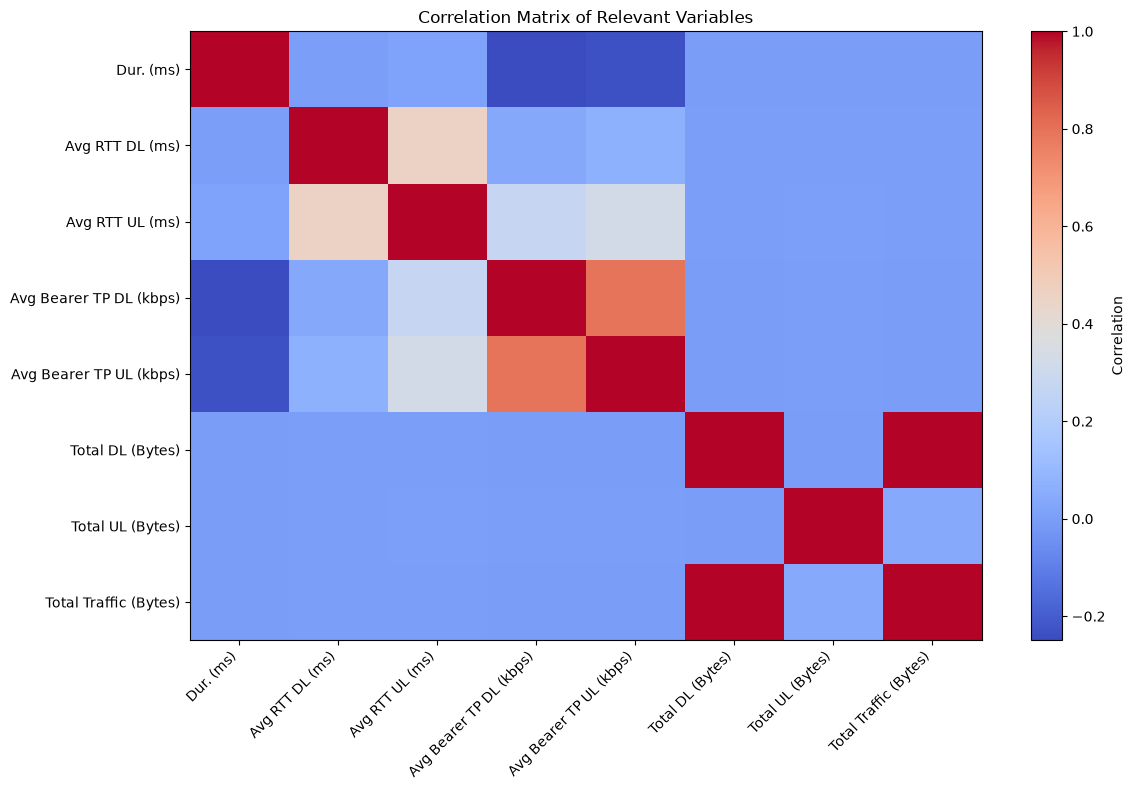

In [99]:
plt.figure(figsize=(12, 8))

plt.imshow(correlation_matrix, aspect="auto", cmap="coolwarm")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix of Relevant Variables")

plt.tight_layout()
plt.show()

In [100]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_data = df[correlation_columns].copy()

scaler = StandardScaler()

pca_scaled = scaler.fit_transform(pca_data)

print("Data standardized successfully")
print("Shape:", pca_scaled.shape)

Data standardized successfully
Shape: (150001, 8)


In [101]:
pca = PCA()

pca_result = pca.fit_transform(pca_scaled)

explained_variance = pca.explained_variance_ratio_

explained_variance

array([2.64514323e-01, 2.49989827e-01, 1.65888379e-01, 1.25013506e-01,
       1.08926831e-01, 5.99028800e-02, 2.57642538e-02, 1.39834140e-16])

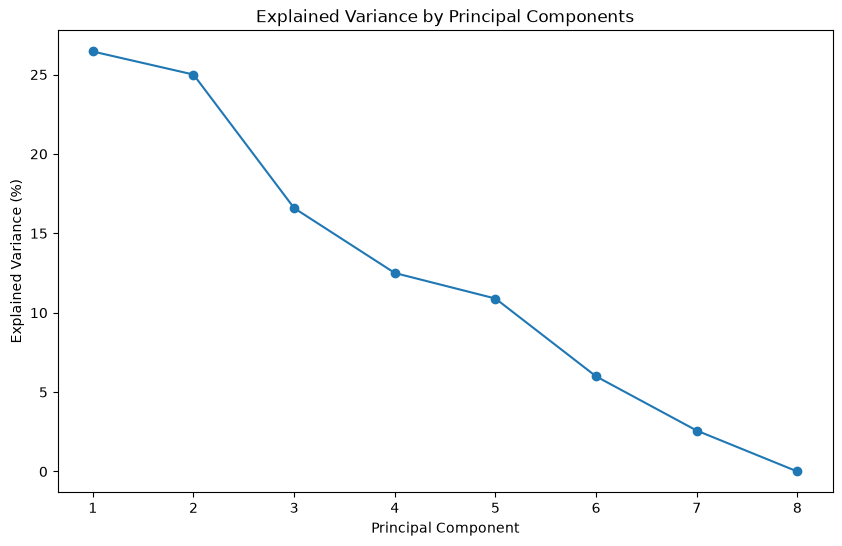

In [102]:
plt.figure(figsize=(10, 6))

components = range(1, len(explained_variance) + 1)

plt.plot(
    components,
    explained_variance * 100,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance by Principal Components")

plt.xticks(components)

plt.show()

In [103]:
cumulative_variance = explained_variance.cumsum()

for i, value in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {value * 100:.2f}%")

PC1: 26.45%
PC2: 51.45%
PC3: 68.04%
PC4: 80.54%
PC5: 91.43%
PC6: 97.42%
PC7: 100.00%
PC8: 100.00%


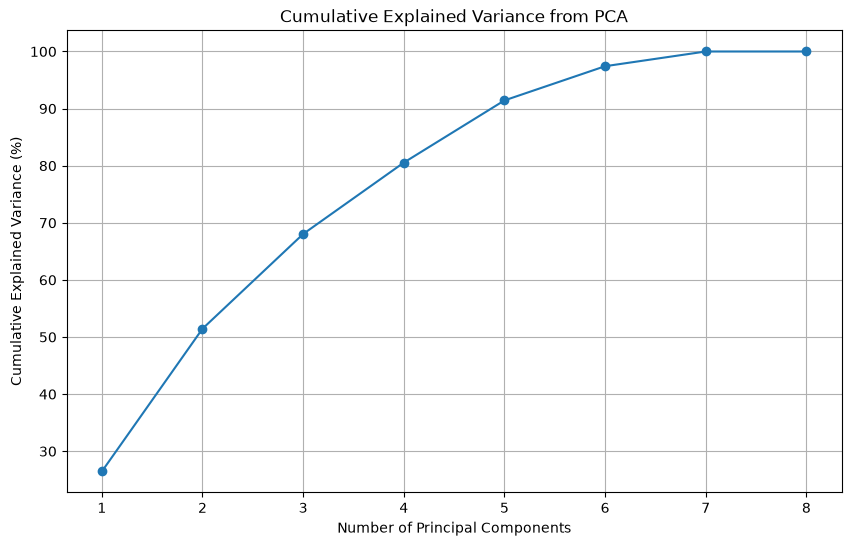

In [104]:
plt.figure(figsize=(10, 6))

plt.plot(
    components,
    cumulative_variance * 100,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance from PCA")

plt.xticks(components)
plt.grid()

plt.show()

In [105]:
user_engagement = df.groupby("MSISDN/Number").agg(
    Sessions_Frequency=("Bearer Id", "count"),
    Total_Duration=("Dur. (ms)", "sum"),
    Total_Traffic=("Total Traffic (Bytes)", "sum")
).reset_index()

user_engagement.head()

,MSISDN/Number,Sessions_Frequency,Total_Duration,Total_Traffic
0,3.360301e+10,2,120325.000000,642463098.0
1,3.360301e+10,1,135718.000000,864013225.0
2,3.360301e+10,1,109906.000000,122304382.0
3,3.360301e+10,1,135968.000000,446771227.0
4,3.360301e+10,2,178817.574377,784493240.0


In [106]:
top_10_sessions = user_engagement.sort_values(
    "Sessions_Frequency",
    ascending=False
).head(10)

top_10_sessions

,MSISDN/Number,Sessions_Frequency,Total_Duration,Total_Traffic
82753,3.369280e+10,24130,2.080633e+09,1.190251e+13
12924,3.362632e+10,18,1.935503e+06,7.971167e+09
5835,3.361489e+10,17,1.831397e+06,8.846226e+09
12578,3.362578e+10,17,1.766590e+06,8.499621e+09
36450,3.365973e+10,16,1.818412e+06,7.705863e+09
75761,3.367588e+10,15,1.524450e+06,7.891111e+09
64516,3.366716e+10,13,1.428218e+06,5.618394e+09
64,3.360313e+10,12,1.310041e+06,4.976195e+09
13392,3.362708e+10,12,1.377436e+06,5.754731e+09
677,3.360452e+10,12,1.375129e+06,5.487855e+09


In [107]:
top_10_duration = user_engagement.sort_values(
    "Total_Duration",
    ascending=False
).head(10)

top_10_duration

,MSISDN/Number,Sessions_Frequency,Total_Duration,Total_Traffic
82753,3.369280e+10,24130,2.080633e+09,1.190251e+13
12924,3.362632e+10,18,1.935503e+06,7.971167e+09
5835,3.361489e+10,17,1.831397e+06,8.846226e+09
36450,3.365973e+10,16,1.818412e+06,7.705863e+09
12578,3.362578e+10,17,1.766590e+06,8.499621e+09
75761,3.367588e+10,15,1.524450e+06,7.891111e+09
64516,3.366716e+10,13,1.428218e+06,5.618394e+09
13392,3.362708e+10,12,1.377436e+06,5.754731e+09
677,3.360452e+10,12,1.375129e+06,5.487855e+09
64,3.360313e+10,12,1.310041e+06,4.976195e+09


In [108]:
top_10_traffic = user_engagement.sort_values(
    "Total_Traffic",
    ascending=False
).head(10)

top_10_traffic

,MSISDN/Number,Sessions_Frequency,Total_Duration,Total_Traffic
82753,3.369280e+10,24130,2.080633e+09,1.190251e+13
5835,3.361489e+10,17,1.831397e+06,8.846226e+09
12578,3.362578e+10,17,1.766590e+06,8.499621e+09
12924,3.362632e+10,18,1.935503e+06,7.971167e+09
75761,3.367588e+10,15,1.524450e+06,7.891111e+09
36450,3.365973e+10,16,1.818412e+06,7.705863e+09
62426,3.366646e+10,11,1.186601e+06,7.308501e+09
56639,3.366471e+10,11,1.097715e+06,6.903964e+09
85854,3.369879e+10,11,1.135385e+06,6.540899e+09
30113,3.365836e+10,10,1.111647e+06,6.452398e+09


In [109]:
#Top 10 Customers by Total Traffic

In [110]:
top_10_traffic = user_engagement.sort_values(
    "Total_Traffic",
    ascending=False
).head(10)

top_10_traffic

,MSISDN/Number,Sessions_Frequency,Total_Duration,Total_Traffic
82753,3.369280e+10,24130,2.080633e+09,1.190251e+13
5835,3.361489e+10,17,1.831397e+06,8.846226e+09
12578,3.362578e+10,17,1.766590e+06,8.499621e+09
12924,3.362632e+10,18,1.935503e+06,7.971167e+09
75761,3.367588e+10,15,1.524450e+06,7.891111e+09
36450,3.365973e+10,16,1.818412e+06,7.705863e+09
62426,3.366646e+10,11,1.186601e+06,7.308501e+09
56639,3.366471e+10,11,1.097715e+06,6.903964e+09
85854,3.369879e+10,11,1.135385e+06,6.540899e+09
30113,3.365836e+10,10,1.111647e+06,6.452398e+09


In [111]:
from sklearn.preprocessing import StandardScaler

engagement_metrics = [
    "Sessions_Frequency",
    "Total_Duration",
    "Total_Traffic"
]

scaler = StandardScaler()

user_engagement_scaled = user_engagement.copy()

user_engagement_scaled[engagement_metrics] = scaler.fit_transform(
    user_engagement[engagement_metrics]
)

user_engagement_scaled.head()

,MSISDN/Number,Sessions_Frequency,Total_Duration,Total_Traffic
0,3.360301e+10,0.004216,-0.003147,-0.004546
1,3.360301e+10,-0.008197,-0.000931,0.001029
2,3.360301e+10,-0.008197,-0.004647,-0.017634
3,3.360301e+10,-0.008197,-0.000895,-0.009470
4,3.360301e+10,0.004216,0.005273,-0.000972


In [112]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

user_engagement_scaled["Engagement_Cluster"] = kmeans.fit_predict(
    user_engagement_scaled[engagement_metrics]
)

user_engagement_scaled.head()

,MSISDN/Number,Sessions_Frequency,Total_Duration,Total_Traffic,Engagement_Cluster
0,3.360301e+10,0.004216,-0.003147,-0.004546,0
1,3.360301e+10,-0.008197,-0.000931,0.001029,0
2,3.360301e+10,-0.008197,-0.004647,-0.017634,0
3,3.360301e+10,-0.008197,-0.000895,-0.009470,0
4,3.360301e+10,0.004216,0.005273,-0.000972,0


In [113]:
#Cluster Summary

In [114]:
cluster_summary = user_engagement_scaled.groupby(
    "Engagement_Cluster"
)[engagement_metrics].agg(
    ["min", "max", "mean", "sum"]
)

cluster_summary

Sessions_Frequency                                      \
                                  min         max        mean         sum   
Engagement_Cluster                                                          
0                           -0.008197    0.016628   -0.006695 -497.336603   
1                          299.483069  299.483069  299.483069  299.483069   
2                            0.004216    0.202809    0.012840  197.853534   

                   Total_Duration                                      \
                              min         max        mean         sum   
Engagement_Cluster                                                      
0                       -0.019438    0.019053   -0.007566 -562.083502   
1                      299.472738  299.472738  299.472738  299.472738   
2                       -0.015867    0.258136    0.017043  262.610764   

                   Total_Traffic                                      
                             min         max        mean         sum  
Engagement_Cluster                                                    
0                      -0.019875    0.024309   -0.007207 -535.411063  
1                     299.475183  299.475183  299.475183  299.475183  
2                      -0.015205    0.201881    0.015312  235.935880

In [115]:
cluster_data = user_engagement.copy()

cluster_data["Engagement_Cluster"] = user_engagement_scaled["Engagement_Cluster"]

cluster_summary = cluster_data.groupby(
    "Engagement_Cluster"
)[engagement_metrics].agg(
    ["min", "max", "mean", "sum"]
)

cluster_summary

Sessions_Frequency                              \
                                  min    max          mean    sum   
Engagement_Cluster                                                  
0                                   1      3      1.121012  83280   
1                               24130  24130  24130.000000  24130   
2                                   2     18      2.694854  41525   

                   Total_Duration                                            \
                              min           max          mean           sum   
Engagement_Cluster                                                            
0                    7.146000e+03  2.745516e+05  8.962548e+04  6.658277e+09   
1                    2.080633e+09  2.080633e+09  2.080633e+09  2.080633e+09   
2                    3.195800e+04  1.935503e+06  2.605870e+05  4.015385e+09   

                   Total_Traffic                                            
                             min           max          mean           sum  
Engagement_Cluster                                                          
0                   3.324901e+07  1.789204e+09  5.366896e+08  3.987067e+13  
1                   1.190251e+13  1.190251e+13  1.190251e+13  1.190251e+13  
2                   2.188439e+08  8.846226e+09  1.431619e+09  2.205982e+13

In [116]:
cluster_counts = user_engagement_scaled["Engagement_Cluster"].value_counts().sort_index()
cluster_counts

Engagement_Cluster
0    74290
1        1
2    15409
Name: count, dtype: int64

In [117]:
cluster_mean = cluster_data.groupby(
    "Engagement_Cluster"
)[engagement_metrics].mean()

cluster_mean

,Sessions_Frequency,Total_Duration,Total_Traffic
Engagement_Cluster,,,
0,1.121012,8.962548e+04,5.366896e+08
1,24130.000000,2.080633e+09,1.190251e+13
2,2.694854,2.605870e+05,1.431619e+09


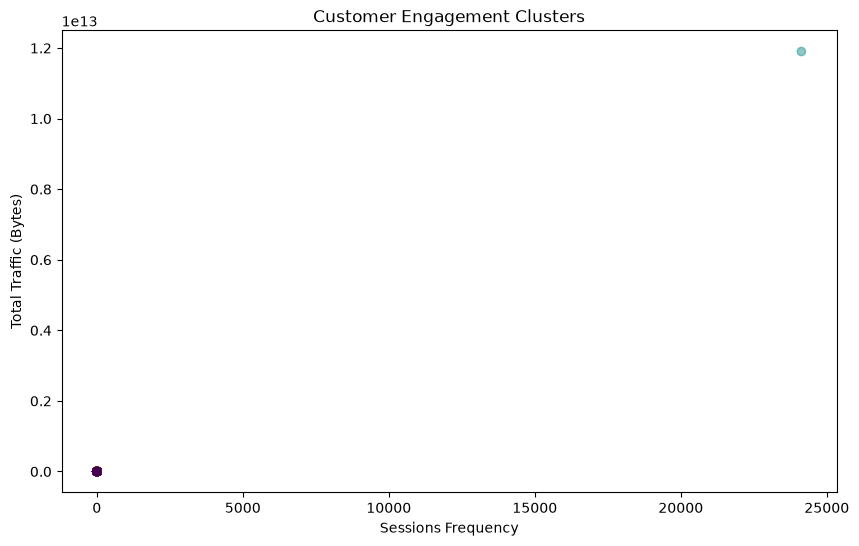

In [118]:
plt.figure(figsize=(10, 6))

plt.scatter(
    cluster_data["Sessions_Frequency"],
    cluster_data["Total_Traffic"],
    c=cluster_data["Engagement_Cluster"],
    alpha=0.5
)

plt.xlabel("Sessions Frequency")
plt.ylabel("Total Traffic (Bytes)")
plt.title("Customer Engagement Clusters")

plt.show()

In [119]:
user_application_total.columns

Index(['MSISDN/Number', 'Social Media Data (Bytes)', 'Google Data (Bytes)',
       'Email Data (Bytes)', 'Youtube Data (Bytes)', 'Netflix Data (Bytes)',
       'Gaming Data (Bytes)', 'Other Data (Bytes)'],
      dtype='str')

In [120]:
print(user_application_total.columns.tolist())

['MSISDN/Number', 'Social Media Data (Bytes)', 'Google Data (Bytes)', 'Email Data (Bytes)', 'Youtube Data (Bytes)', 'Netflix Data (Bytes)', 'Gaming Data (Bytes)', 'Other Data (Bytes)']


In [121]:
application_columns = [
    "Social Media Data (Bytes)",
    "Google Data (Bytes)",
    "Email Data (Bytes)",
    "Youtube Data (Bytes)",
    "Netflix Data (Bytes)",
    "Gaming Data (Bytes)",
    "Other Data (Bytes)"
]

for column in application_columns:
    top_10 = user_application_total.nlargest(10, column)

    print("\nTop 10 Customers for", column)
    print(top_10[["MSISDN/Number", column]])


Top 10 Customers for Social Media Data (Bytes)
        MSISDN/Number  Social Media Data (Bytes)
13526    3.362632e+10                 43374779.0
92923    3.376054e+10                 39783189.0
37052    3.365973e+10                 35412358.0
6437     3.361489e+10                 28294544.0
13180    3.362578e+10                 27135500.0
65118    3.366716e+10                 24247850.0
106137   3.378632e+10                 23974919.0
70960    3.366907e+10                 23800834.0
666      3.360313e+10                 23077825.0
31331    3.365849e+10                 23000066.0

Top 10 Customers for Google Data (Bytes)
        MSISDN/Number  Google Data (Bytes)
13526    3.362632e+10          152191852.0
13180    3.362578e+10          142307915.0
6437     3.361489e+10          127973787.0
92923    3.376054e+10          123223099.0
37052    3.365973e+10          116516345.0
106137   3.378632e+10          110254484.0
76363    3.367588e+10          109860502.0
65118    3.366716e+10      

In [122]:
application_usage = user_application_total[
    application_columns
].sum().sort_values(ascending=False)

application_usage

Gaming Data (Bytes)          6.408892e+13
Other Data (Bytes)           6.395425e+13
Youtube Data (Bytes)         3.372204e+12
Netflix Data (Bytes)         3.370060e+12
Google Data (Bytes)          1.162853e+12
Email Data (Bytes)           3.364677e+11
Social Media Data (Bytes)    2.722655e+11
dtype: float64

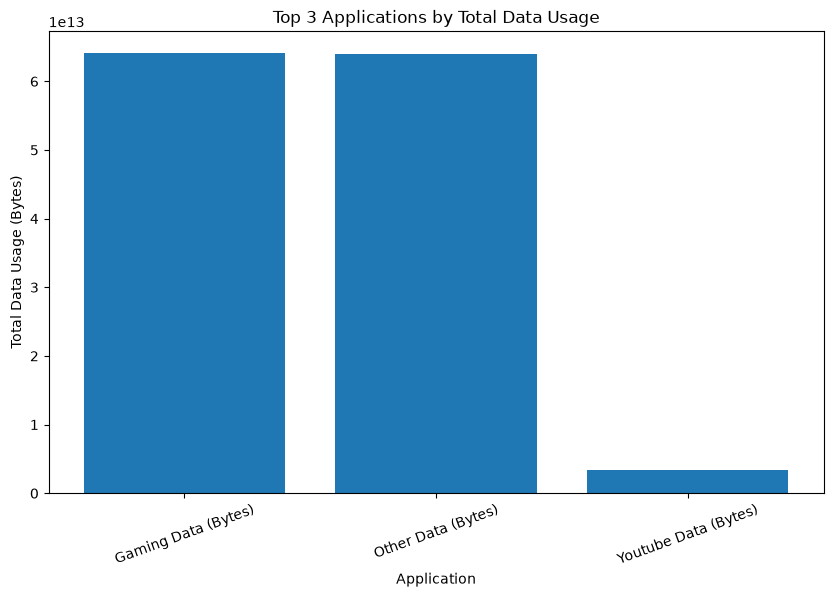

In [123]:
top_3_apps = application_usage.head(3)

plt.figure(figsize=(10, 6))

plt.bar(
    top_3_apps.index,
    top_3_apps.values
)

plt.xlabel("Application")
plt.ylabel("Total Data Usage (Bytes)")
plt.title("Top 3 Applications by Total Data Usage")

plt.xticks(rotation=20)

plt.show()

In [124]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans_model.fit(
        user_engagement_scaled[engagement_metrics]
    )
    
    inertia.append(kmeans_model.inertia_)

inertia

[37.585849434009425,
 18.548466828398926,
 12.501043906898987,
 10.379147283192749,
 8.891910775850294,
 7.900585111807061,
 6.672231738729042,
 5.851632007889264,
 5.320294220268982]

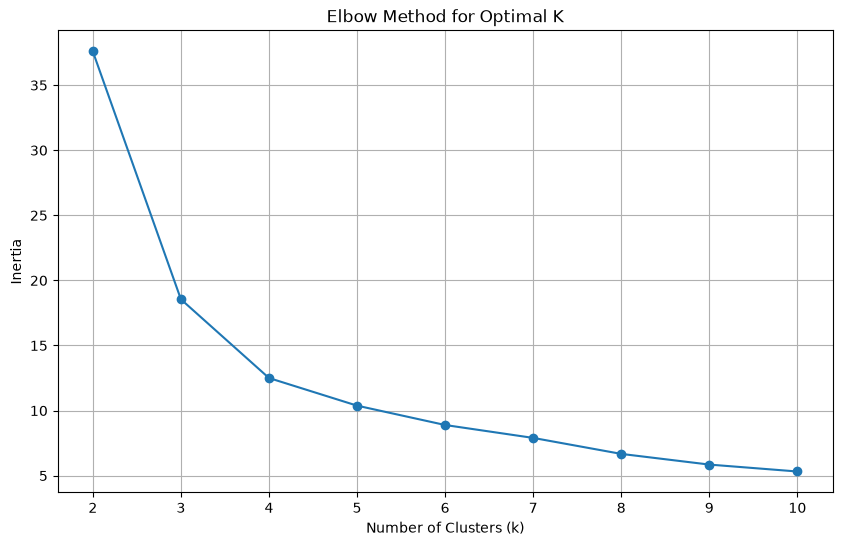

In [125]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(range(2, 11))
plt.grid()

plt.show()

In [126]:
optimal_k = 4

kmeans_optimal = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

user_engagement_scaled["Optimized_Cluster"] = kmeans_optimal.fit_predict(
    user_engagement_scaled[engagement_metrics]
)

user_engagement_scaled["Optimized_Cluster"].value_counts()

Optimized_Cluster
0    68885
2    17409
3     3405
1        1
Name: count, dtype: int64

In [127]:
cluster_summary_4 = user_engagement.groupby(
    user_engagement_scaled["Optimized_Cluster"]
)[engagement_metrics].agg(
    ["min", "max", "mean", "sum"]
)

cluster_summary_4

Sessions_Frequency                              \
                                 min    max          mean    sum   
Optimized_Cluster                                                  
0                                  1      3      1.052159  72478   
1                              24130  24130  24130.000000  24130   
2                                  1      4      2.175886  37880   
3                                  3     18      4.242878  14447   

                  Total_Duration                                            \
                             min           max          mean           sum   
Optimized_Cluster                                                            
0                   7.146000e+03  2.113840e+05  8.614027e+04  5.933773e+09   
1                   2.080633e+09  2.080633e+09  2.080633e+09  2.080633e+09   
2                   2.199400e+04  4.389820e+05  1.919621e+05  3.341868e+09   
3                   1.168000e+05  1.935503e+06  4.105786e+05  1.398020e+09   

                  Total_Traffic                                            
                            min           max          mean           sum  
Optimized_Cluster                                                          
0                  3.324901e+07  1.270936e+09  5.068407e+08  3.491372e+13  
1                  1.190251e+13  1.190251e+13  1.190251e+13  1.190251e+13  
2                  1.669101e+08  2.522556e+09  1.119206e+09  1.948426e+13  
3                  7.456679e+08  8.846226e+09  2.212194e+09  7.532521e+12

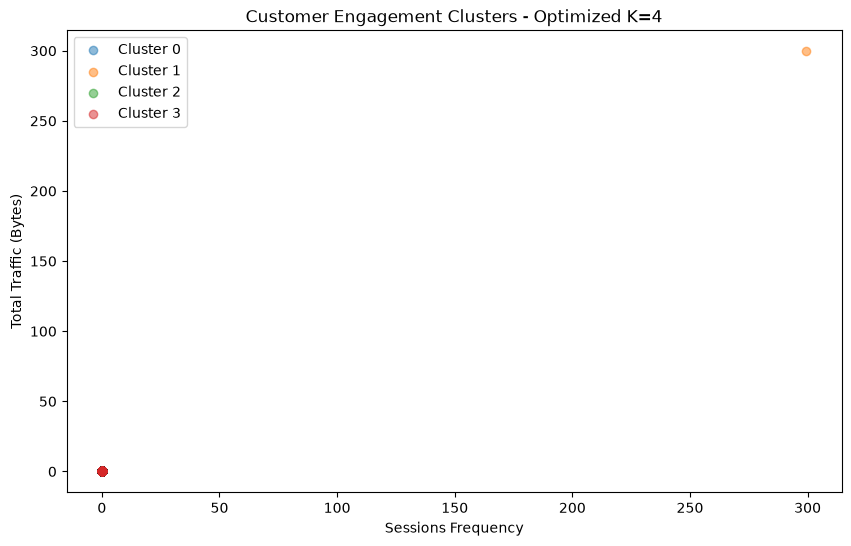

In [128]:
plt.figure(figsize=(10, 6))

for cluster in sorted(user_engagement_scaled["Optimized_Cluster"].unique()):
    cluster_points = user_engagement_scaled[
        user_engagement_scaled["Optimized_Cluster"] == cluster
    ]

    plt.scatter(
        cluster_points["Sessions_Frequency"],
        cluster_points["Total_Traffic"],
        label=f"Cluster {cluster}",
        alpha=0.5
    )

plt.xlabel("Sessions Frequency")
plt.ylabel("Total Traffic (Bytes)")
plt.title("Customer Engagement Clusters - Optimized K=4")
plt.legend()

plt.show()

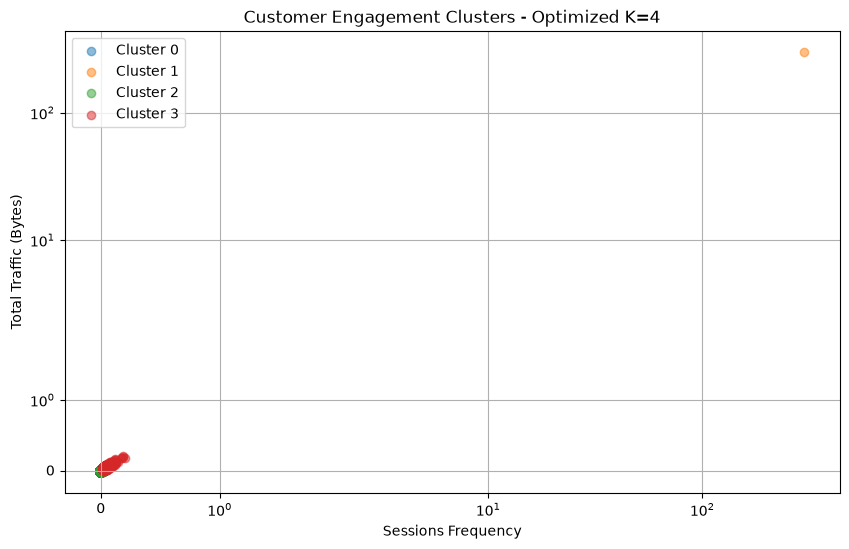

In [129]:
plt.figure(figsize=(10, 6))

for cluster in sorted(user_engagement_scaled["Optimized_Cluster"].unique()):
    cluster_points = user_engagement_scaled[
        user_engagement_scaled["Optimized_Cluster"] == cluster
    ]

    plt.scatter(
        cluster_points["Sessions_Frequency"],
        cluster_points["Total_Traffic"],
        label=f"Cluster {cluster}",
        alpha=0.5
    )

plt.xscale("symlog")
plt.yscale("symlog")

plt.xlabel("Sessions Frequency")
plt.ylabel("Total Traffic (Bytes)")
plt.title("Customer Engagement Clusters - Optimized K=4")
plt.legend()
plt.grid()

plt.show()

In [130]:
cluster_mean_4 = user_engagement.groupby(
    user_engagement_scaled["Optimized_Cluster"]
)[engagement_metrics].mean()

cluster_mean_4

,Sessions_Frequency,Total_Duration,Total_Traffic
Optimized_Cluster,,,
0,1.052159,8.614027e+04,5.068407e+08
1,24130.000000,2.080633e+09,1.190251e+13
2,2.175886,1.919621e+05,1.119206e+09
3,4.242878,4.105786e+05,2.212194e+09


In [131]:
user_experience = df.groupby("MSISDN/Number").agg(
    Avg_TCP_DL=("TCP DL Retrans. Vol (Bytes)", "mean"),
    Avg_TCP_UL=("TCP UL Retrans. Vol (Bytes)", "mean"),
    Avg_RTT_DL=("Avg RTT DL (ms)", "mean"),
    Avg_RTT_UL=("Avg RTT UL (ms)", "mean"),
    Avg_TP_DL=("Avg Bearer TP DL (kbps)", "mean"),
    Avg_TP_UL=("Avg Bearer TP UL (kbps)", "mean"),
    Handset_Type=("Handset Type", "first")
).reset_index()

user_experience["Avg_TCP_Retransmission"] = (
    user_experience["Avg_TCP_DL"] +
    user_experience["Avg_TCP_UL"]
) / 2

user_experience["Avg_RTT"] = (
    user_experience["Avg_RTT_DL"] +
    user_experience["Avg_RTT_UL"]
) / 2

user_experience["Avg_Throughput"] = (
    user_experience["Avg_TP_DL"] +
    user_experience["Avg_TP_UL"]
) / 2

user_experience = user_experience[
    [
        "MSISDN/Number",
        "Avg_TCP_Retransmission",
        "Avg_RTT",
        "Handset_Type",
        "Avg_Throughput"
    ]
]

user_experience.head()

,MSISDN/Number,Avg_TCP_Retransmission,Avg_RTT,Handset_Type,Avg_Throughput
0,3.360301e+10,5.615119e+06,39.614647,Samsung Galaxy Note 8 (Sm-N950F),2217.75
1,3.360301e+10,1.078479e+07,63.729294,Samsung Galaxy S7 (Sm-G930X),7.50
2,3.360301e+10,1.078479e+07,11.000000,Apple iPhone X (A1901),57.50
3,3.360301e+10,1.078479e+07,13.500000,Apple iPhone 7 (A1778),33.50
4,3.360301e+10,1.078479e+07,23.500000,Apple iPhone 6S (A1688),31.50


In [132]:
top_10_tcp = user_experience.nlargest(
    10, "Avg_TCP_Retransmission"
)
print("Top 10 TCP Retransmission:")
print(top_10_tcp[["MSISDN/Number", "Avg_TCP_Retransmission"]])

bottom_10_tcp = user_experience.nsmallest(
    10, "Avg_TCP_Retransmission"
)

print("\nBottom 10 TCP Retransmission:")
print(bottom_10_tcp[["MSISDN/Number", "Avg_TCP_Retransmission"]])

top_10_rtt = user_experience.nlargest(
    10, "Avg_RTT"
)

print("\nTop 10 RTT:")
print(top_10_rtt[["MSISDN/Number", "Avg_RTT"]])

bottom_10_rtt = user_experience.nsmallest(
    10, "Avg_RTT"
)

print("\nBottom 10 RTT:")
print(bottom_10_rtt[["MSISDN/Number", "Avg_RTT"]])

top_10_throughput = user_experience.nlargest(
    10, "Avg_Throughput"
)

print("\nTop 10 Throughput:")
print(top_10_throughput[["MSISDN/Number", "Avg_Throughput"]])

bottom_10_throughput = user_experience.nsmallest(
    10, "Avg_Throughput"
)

print("\nBottom 10 Throughput:")
print(bottom_10_throughput[["MSISDN/Number", "Avg_Throughput"]])

Top 10 TCP Retransmission:
       MSISDN/Number  Avg_TCP_Retransmission
72148   3.366969e+10            2.530242e+07
36411   3.365971e+10            2.515900e+07
26112   3.365088e+10            2.512970e+07
43183   3.366135e+10            2.508386e+07
31296   3.365863e+10            2.506801e+07
26632   3.365099e+10            2.506671e+07
71669   3.366951e+10            2.504390e+07
54318   3.366403e+10            2.501955e+07
55590   3.366441e+10            2.500203e+07
32074   3.365878e+10            2.492142e+07

Bottom 10 TCP Retransmission:
       MSISDN/Number  Avg_TCP_Retransmission
22870   3.365013e+10                    48.5
5757    3.361478e+10                    64.0
12944   3.362636e+10                    67.0
1575    3.360783e+10                    71.5
25261   3.365068e+10                    88.0
77498   3.367937e+10                    89.5
88794   3.369969e+10                    91.0
86692   3.369904e+10                    94.5
76009   3.367640e+10                   104

In [133]:
print("Most Frequent TCP Retransmission:")
print(
    user_experience["Avg_TCP_Retransmission"]
    .value_counts()
    .head(10)
)
print("\nMost Frequent RTT:")
print(
    user_experience["Avg_RTT"]
    .value_counts()
    .head(10)
)
print("\nMost Frequent Throughput:")
print(
    user_experience["Avg_Throughput"]
    .value_counts()
    .head(10)
)

Most Frequent TCP Retransmission:
Avg_TCP_Retransmission
1.078479e+07    47125
1.040560e+07      299
1.040562e+07      148
3.804943e+05      123
3.811593e+05       68
3.798753e+05       67
1.040562e+07       67
1.059520e+07       64
3.798483e+05       61
1.040629e+07       60
Name: count, dtype: int64

Most Frequent RTT:
Avg_RTT
63.729294    15376
14.500000     2477
19.500000     1990
19.000000     1358
20.000000     1338
15.000000     1334
14.000000     1217
24.500000     1095
20.500000     1040
15.500000     1025
Name: count, dtype: int64

Most Frequent Throughput:
Avg_Throughput
7535.237287    2588
7.500000       2145
31.500000      1771
4857.153017    1628
3620.608845    1337
48.500000       931
45.000000       918
49.000000       882
49.500000       788
48.000000       778
Name: count, dtype: int64


In [134]:
throughput_handset = user_experience.groupby(
    "Handset_Type"
)["Avg_Throughput"].mean().sort_values(ascending=False)

throughput_handset.head(20)

Handset_Type
Huawei Y6 Prime 2018                         7918.022963
Lg G6+                                       7844.022963
Nokia 1661-2 1661                            7837.500000
Huawei Aum-Al00                              7829.022963
Xiaomi Communica. B6L                        7688.714323
Tecno Telecom (H. Phantom6 Plus              7680.522963
Huawei Hwi-Al00                              7672.022963
Shenzhen Leagoo. Leagoo S8                   7661.022963
Huawei Pele                                  7603.522963
Oppo Cph1701                                 7535.237287
Ovvi-Cellphone T. Echo                       7535.237287
Xiaomi Communica. Mi 6                       7535.237287
Zyxel Communicat. Sbg3600                    7535.237287
Oppo Cph1723                                 7535.237287
Neel Enterprise Kolor Crosscalltrekker-X2    7535.237287
Samsung Galaxy S9+                           7535.237287
Huawei E8372                                 7535.237287
Sfr Starxtrem7    

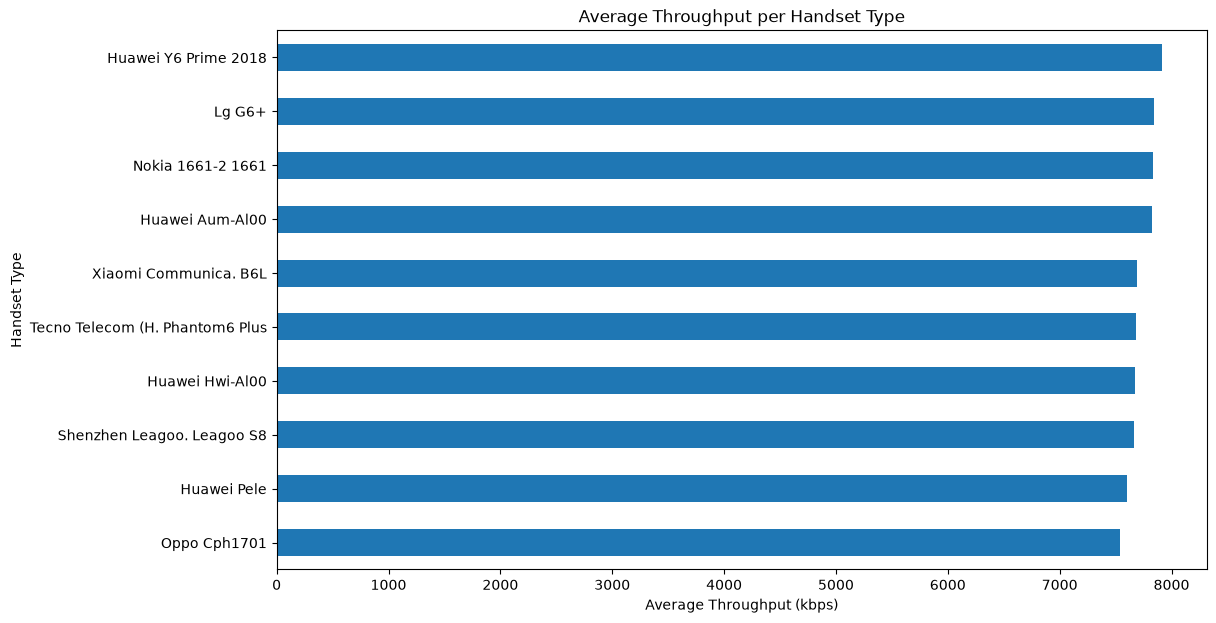

In [135]:
plt.figure(figsize=(12, 7))

throughput_handset.head(10).sort_values().plot(kind="barh")

plt.xlabel("Average Throughput (kbps)")
plt.ylabel("Handset Type")
plt.title("Average Throughput per Handset Type")

plt.show()

In [136]:
tcp_handset = user_experience.groupby(
    "Handset_Type"
)["Avg_TCP_Retransmission"].mean().sort_values(
    ascending=False
)

tcp_handset.head(20)

Handset_Type
Samsung Galaxy Core 2 (Sm-G355X)         2.327950e+07
A-Link Telecom I. Cubot Note S           2.070587e+07
Asustek Asus Zenfone Selfie Zd551Kl      1.920872e+07
Spa Condor Elect. Allure M1 Plus         1.588508e+07
Quartel Infotech. Maximus M84            1.564691e+07
Tcl Communicatio. Pixi 4 6 3G Android    1.543098e+07
Lg-M400Dy                                1.420619e+07
Rim Blackberry Stl100-2 Z10 Rfh121Lw     1.412459e+07
Lg G6+                                   1.353974e+07
Samsung Galaxy J3 (Sm-J327)              1.268490e+07
Zyxel Communicat. Lte7460                1.230134e+07
Samsung Galaxy J1 Mini (Sm-J105X)        1.198209e+07
Samsung Galaxy A7 Sm-A720F Ds            1.173371e+07
Sierra Wireless Usb305                   1.096653e+07
Rim Blackberry Rhm181Lw (Stv100-4)       1.078479e+07
Rim Blackberry 9790                      1.078479e+07
Rim Blackberry 9800                      1.078479e+07
Rim Blackberry 9900                      1.078479e+07
Rim Blackberry 

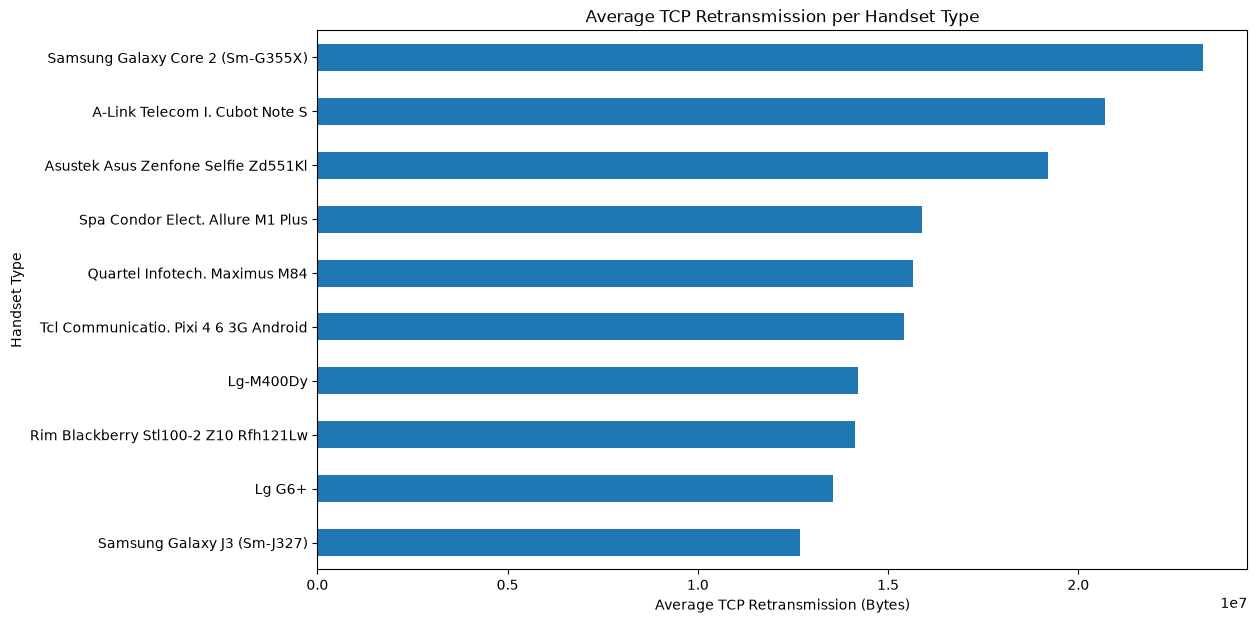

In [137]:
plt.figure(figsize=(12, 7))

tcp_handset.head(10).sort_values().plot(kind="barh")

plt.xlabel("Average TCP Retransmission (Bytes)")
plt.ylabel("Handset Type")
plt.title("Average TCP Retransmission per Handset Type")

plt.show()

In [138]:
experience_metrics = [
    "Avg_TCP_Retransmission",
    "Avg_RTT",
    "Avg_Throughput"
]

experience_scaled = user_experience.copy()

scaler = StandardScaler()

experience_scaled[experience_metrics] = scaler.fit_transform(
    experience_scaled[experience_metrics]
)

experience_scaled.head()

,MSISDN/Number,Avg_TCP_Retransmission,Avg_RTT,Handset_Type,Avg_Throughput
0,3.360301e+10,-0.390345,0.038269,Samsung Galaxy Note 8 (Sm-N950F),0.255241
1,3.360301e+10,0.756274,1.169001,Samsung Galaxy S7 (Sm-G930X),-0.739092
2,3.360301e+10,0.756274,-1.303467,Apple iPhone X (A1901),-0.716599
3,3.360301e+10,0.756274,-1.186243,Apple iPhone 7 (A1778),-0.727396
4,3.360301e+10,0.756274,-0.717344,Apple iPhone 6S (A1688),-0.728295


In [139]:
from sklearn.cluster import KMeans

kmeans_experience = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

experience_scaled["Experience_Cluster"] = kmeans_experience.fit_predict(
    experience_scaled[experience_metrics]
)

experience_scaled["Experience_Cluster"].value_counts()

Experience_Cluster
0    35947
1    31736
2    22017
Name: count, dtype: int64

In [140]:
experience_cluster_mean = experience_scaled.groupby(
    "Experience_Cluster"
)[experience_metrics].mean()

experience_cluster_mean

,Avg_TCP_Retransmission,Avg_RTT,Avg_Throughput
Experience_Cluster,,,
0,0.644147,-0.813822,-0.570052
1,-1.162334,0.099162,0.997884
2,0.623730,1.185786,-0.507661


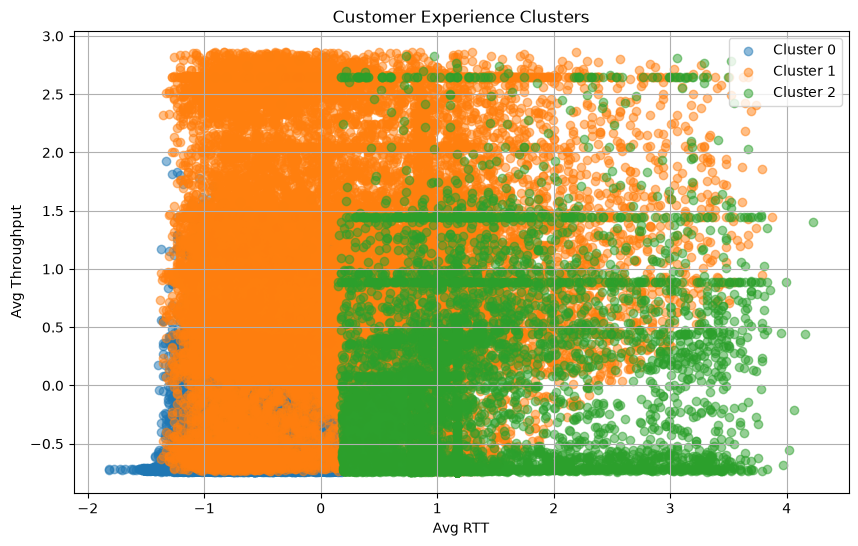

In [141]:
plt.figure(figsize=(10, 6))

for cluster in sorted(experience_scaled["Experience_Cluster"].unique()):
    cluster_data = experience_scaled[
        experience_scaled["Experience_Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["Avg_RTT"],
        cluster_data["Avg_Throughput"],
        label=f"Cluster {cluster}",
        alpha=0.5
    )

plt.xlabel("Avg RTT")
plt.ylabel("Avg Throughput")
plt.title("Customer Experience Clusters")
plt.legend()
plt.grid(True)

plt.show()

In [142]:
experience_cluster_summary = experience_scaled.groupby(
    "Experience_Cluster"
)[experience_metrics].agg(
    ["min", "max", "mean"]
)

experience_cluster_summary

Avg_TCP_Retransmission                       Avg_RTT  \
                                      min       max      mean       min   
Experience_Cluster                                                        
0                               -1.551513  3.976248  0.644147 -1.819256   
1                               -1.635753  1.918585 -1.162334 -1.381617   
2                               -1.635744  3.937938  0.623730  0.150118   

                                       Avg_Throughput                      
                         max      mean            min       max      mean  
Experience_Cluster                                                         
0                   0.190661 -0.813822      -0.742241  2.824368 -0.570052  
1                   3.877861  0.099162      -0.742241  2.863057  0.997884  
2                   4.229535  1.185786      -0.742466  2.831116 -0.507661

In [143]:
engagement_centers = kmeans.cluster_centers_
experience_centers = kmeans_experience.cluster_centers_

print("Engagement Cluster Centers:")
print(engagement_centers)

print("\nExperience Cluster Centers:")
print(experience_centers)

Engagement Cluster Centers:
[[-6.83074613e-03 -7.77630201e-03 -7.21642304e-03]
 [ 2.99483069e+02  2.99472738e+02  2.99475183e+02]
 [ 1.23786264e-02  1.66351893e-02  1.41150345e-02]]

Experience Cluster Centers:
[[ 0.64348662 -0.81375736 -0.56965728]
 [-1.16265814  0.10011192  0.99807955]
 [ 0.62469338  1.18551001 -0.5080616 ]]


In [144]:
from scipy.spatial.distance import cdist

less_engaged_centroid = engagement_centers[0]

user_engagement_scaled["Engagement_Score"] = cdist(
    user_engagement_scaled[engagement_metrics],
    [less_engaged_centroid],
    metric="euclidean"
).flatten()

user_engagement_scaled.head()

,MSISDN/Number,Sessions_Frequency,Total_Duration,Total_Traffic,Engagement_Cluster,Optimized_Cluster,Engagement_Score
0,3.360301e+10,0.004216,-0.003147,-0.004546,0,0,0.012271
1,3.360301e+10,-0.008197,-0.000931,0.001029,0,0,0.010803
2,3.360301e+10,-0.008197,-0.004647,-0.017634,0,0,0.010963
3,3.360301e+10,-0.008197,-0.000895,-0.009470,0,0,0.007368
4,3.360301e+10,0.004216,0.005273,-0.000972,0,2,0.018201


In [145]:
worst_experience_centroid = experience_centers[2]
experience_scaled["Experience_Score"] = cdist(
    experience_scaled[experience_metrics],
    [worst_experience_centroid],
    metric="euclidean"
).flatten()

experience_scaled.head()

,MSISDN/Number,Avg_TCP_Retransmission,Avg_RTT,Handset_Type,Avg_Throughput,Experience_Cluster,Experience_Score
0,3.360301e+10,-0.390345,0.038269,Samsung Galaxy Note 8 (Sm-N950F),0.255241,1,1.711460
1,3.360301e+10,0.756274,1.169001,Samsung Galaxy S7 (Sm-G930X),-0.739092,2,0.266385
2,3.360301e+10,0.756274,-1.303467,Apple iPhone X (A1901),-0.716599,0,2.501162
3,3.360301e+10,0.756274,-1.186243,Apple iPhone 7 (A1778),-0.727396,0,2.385504
4,3.360301e+10,0.756274,-0.717344,Apple iPhone 6S (A1688),-0.728295,0,1.920070


In [146]:
satisfaction_data = pd.DataFrame({
    "MSISDN/Number": user_engagement_scaled["MSISDN/Number"],
    "Engagement_Score": user_engagement_scaled["Engagement_Score"],
    "Experience_Score": experience_scaled["Experience_Score"]
})

satisfaction_data["Satisfaction_Score"] = (
    satisfaction_data["Engagement_Score"] +
    satisfaction_data["Experience_Score"]
) / 2

top_10_satisfied = satisfaction_data.sort_values(
    "Satisfaction_Score",
    ascending=False
).head(10)

top_10_satisfied

,MSISDN/Number,Engagement_Score,Experience_Score,Satisfaction_Score
82753,3.369280e+10,518.721974,1.459253,260.090614
33682,3.365912e+10,0.009073,4.837255,2.423164
71669,3.366951e+10,0.009479,4.761145,2.385312
43183,3.366135e+10,0.009116,4.747642,2.378379
72148,3.366969e+10,0.011436,4.700984,2.356210
39297,3.366039e+10,0.005632,4.698517,2.352074
62034,3.366631e+10,0.001516,4.692390,2.346953
58931,3.366532e+10,0.003419,4.665522,2.334471
8579,3.361936e+10,0.012443,4.642488,2.327466
63477,3.366682e+10,0.006096,4.648327,2.327211


In [147]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = satisfaction_data[
    ["Engagement_Score", "Experience_Score"]
]

y = satisfaction_data["Satisfaction_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

regression_model = LinearRegression()

regression_model.fit(X_train, y_train)

y_pred = regression_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 2.676840008212163e-30
R2 Score: 1.0


In [148]:
from sklearn.cluster import KMeans

satisfaction_features = satisfaction_data[
    ["Engagement_Score", "Experience_Score"]
]

kmeans_satisfaction = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

satisfaction_data["Satisfaction_Cluster"] = (
    kmeans_satisfaction.fit_predict(satisfaction_features)
)

satisfaction_data["Satisfaction_Cluster"].value_counts()

Satisfaction_Cluster
0    89699
1        1
Name: count, dtype: int64

In [149]:
cluster_satisfaction_summary = satisfaction_data.groupby(
    "Satisfaction_Cluster"
)[["Engagement_Score", "Experience_Score", "Satisfaction_Score"]].mean()

cluster_satisfaction_summary

,Engagement_Score,Experience_Score,Satisfaction_Score
Satisfaction_Cluster,,,
0,0.014591,1.990158,1.002375
1,518.721974,1.459253,260.090614


In [150]:
final_satisfaction_table = satisfaction_data[
    [
        "MSISDN/Number",
        "Engagement_Score",
        "Experience_Score",
        "Satisfaction_Score"
    ]
]

final_satisfaction_table.head()

,MSISDN/Number,Engagement_Score,Experience_Score,Satisfaction_Score
0,3.360301e+10,0.012271,1.711460,0.861866
1,3.360301e+10,0.010803,0.266385,0.138594
2,3.360301e+10,0.010963,2.501162,1.256062
3,3.360301e+10,0.007368,2.385504,1.196436
4,3.360301e+10,0.018201,1.920070,0.969136


In [151]:
%pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [152]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Anish@2026"
)

cur = conn.cursor()

print("MySQL connected successfully")

MySQL connected successfully


In [153]:
cur.execute("SHOW DATABASES")

for db in cur:
    print(db[0])

college
information_schema
mysql
performance_schema
sys
telecom_db


In [154]:
cur.execute("CREATE DATABASE IF NOT EXISTS Telecom_db")
conn.commit()

print("Telecom_db is ready")

Telecom_db is ready


In [155]:
cur.execute("CREATE DATABASE Telecom_db")
conn.commit()

print("Telecom_db created successfully")

DatabaseError: 1007 (HY000): Can't create database 'telecom_db'; database exists

In [156]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Anish@2026",
    database="Telecom_db"
)

cur = conn.cursor()

print("Telecom_db connected successfully")

Telecom_db connected successfully


In [157]:
create_table_query = """
CREATE TABLE IF NOT EXISTS satisfaction_scores (
    MSISDN_Number BIGINT,
    Engagement_Score DOUBLE,
    Experience_Score DOUBLE,
    Satisfaction_Score DOUBLE
)
"""

cur.execute(create_table_query)
conn.commit()

print("satisfaction_scores table created successfully")

satisfaction_scores table created successfully


In [158]:
insert_query = """
INSERT INTO satisfaction_scores
(
    MSISDN_Number,
    Engagement_Score,
    Experience_Score,
    Satisfaction_Score
)
VALUES (%s, %s, %s, %s)
"""

for _, row in final_satisfaction_table.iterrows():
    cur.execute(
        insert_query,
        (
            int(row["MSISDN/Number"]),
            float(row["Engagement_Score"]),
            float(row["Experience_Score"]),
            float(row["Satisfaction_Score"])
        )
    )

conn.commit()

print("Data inserted successfully")

Data inserted successfully


In [159]:
query = """
SELECT
    MSISDN_Number,
    Engagement_Score,
    Experience_Score,
    Satisfaction_Score
FROM satisfaction_scores
LIMIT 10
"""

cur.execute(query)

result = cur.fetchall()

for row in result:
    print(row)

(33601754045, 0.013155889422057568, 0.25523561867694106, 0.13419575404949932)
(33601756502, 0.029287035123850128, 1.5971588917732455, 0.8132229634485478)
(33601759499, 0.004193970134071545, 0.25258754307562664, 0.12839075660484908)
(33601761539, 0.004646207877351133, 0.2571523399260259, 0.1308992739016885)
(33601763446, 0.010178510397512453, 3.8562382906536636, 1.933208400525588)
(33601768566, 0.03760933840065423, 1.9860547744374357, 1.011832056419045)
(33601769835, 0.012264425848220175, 2.3201541468175586, 1.1662092863328894)
(33601772244, 0.04441793486176689, 0.7165550073629668, 0.3804864711123669)
(33601772284, 0.05762667316502805, 2.3655191341695594, 1.2115729036672938)
(33601772883, 0.007754267088276816, 1.160224586250661, 0.583989426669469)


In [160]:
%pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [161]:
import mlflow
print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.1


In [162]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow_tracking.db")

mlflow.set_experiment("Telecom Customer Satisfaction Model")

print("MLflow tracking setup completed successfully")

MLflow tracking setup completed successfully


In [163]:
import mlflow
import mlflow.sklearn
mlflow.set_experiment("Telecom Customer Satisfaction Model")
print("MLflow tracking setup completed")

MLflow tracking setup completed


In [164]:
import mlflow
from pathlib import Path

# Safe MLflow database location
mlflow_db = Path.home() / "mlflow_tracking.db"
mlflow_uri = "sqlite:///" + str(mlflow_db).replace("\\", "/")

mlflow.set_tracking_uri(mlflow_uri)

mlflow.set_experiment("Telecom Customer Satisfaction Model")

print("MLflow tracking setup completed successfully")
print("Tracking database:", mlflow_db)

MLflow tracking setup completed successfully
Tracking database: C:\Users\Anish kumar tiwari\mlflow_tracking.db


In [165]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow_tracking.db")

mlflow.set_experiment("Telecom Customer Satisfaction Model")

print("MLflow tracking setup completed successfully")

MLflow tracking setup completed successfully


In [166]:
%whos

Variable                       Type                Data/Info
------------------------------------------------------------
IQR                            float64             422597965.0
KMeans                         ABCMeta             <class 'sklearn.cluster._kmeans.KMeans'>
LinearRegression               ABCMeta             <class 'sklearn.linear_mo<...>._base.LinearRegression'>
PCA                            ABCMeta             <class 'sklearn.decomposition._pca.PCA'>
Path                           type                <class 'pathlib.Path'>
Q1                             float64             243107173.0
Q3                             float64             665705138.0
StandardScaler                 type                <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                              DataFrame           Shape: (89700, 2)
X_test                         DataFrame           Shape: (17940, 2)
X_train                        DataFrame           Shape: (71760, 2)
applicatio

In [167]:
import mlflow
import mlflow.sklearn
import time


with mlflow.start_run(run_name="Telecom Satisfaction Regression"):

    
    mlflow.set_tag("source", "Jupyter Notebook - Telecom Customer Analysis")
    mlflow.set_tag("task", "Task 4.7 Model Deployment Tracking")
    mlflow.set_tag("code_version", "v1.0")

   
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("features", "Engagement_Score, Experience_Score")
    mlflow.log_param("training_rows", len(X_train))
    mlflow.log_param("test_rows", len(X_test))

    
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("R2_Score", r2)

    
    mlflow.sklearn.log_model(
        regression_model,
        "satisfaction_regression_model"
    )

    print("Model tracked successfully")
    print("MSE:", mse)
    print("R2 Score:", r2)

2026/09/17 23:31:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model tracked successfully
MSE: 2.676840008212163e-30
R2 Score: 1.0


In [168]:
runs = mlflow.search_runs()

runs[[
    "run_id",
    "status",
    "start_time",
    "end_time",
    "metrics.MSE",
    "metrics.R2_Score"
]].head()

,run_id,status,start_time,end_time,metrics.MSE,metrics.R2_Score
0,38e7e409808c4f1b9d6a3630801746e8,FINISHED,2026-09-17 18:01:13.587000+00:00,2026-09-17 18:01:42.319000+00:00,2.676840e-30,1.0
1,6160553154ef42f8b545419b5680f580,FINISHED,2026-09-17 15:48:45.128000+00:00,2026-09-17 15:49:46.049000+00:00,1.647366e-30,1.0
2,8ccda012ce2b4ba09f6cd88879627054,FINISHED,2026-09-17 15:19:38.282000+00:00,2026-09-17 15:23:52.957000+00:00,7.726959e-31,1.0


In [169]:
tracking_report = pd.DataFrame({
    "Run_ID": [mlflow.active_run().info.run_id if mlflow.active_run() else "Completed Run"],
    "Model": ["Linear Regression"],
    "Code_Version": ["v1.0"],
    "MSE": [mse],
    "R2_Score": [r2],
    "Training_Rows": [len(X_train)],
    "Test_Rows": [len(X_test)]
})

tracking_report

,Run_ID,Model,Code_Version,MSE,R2_Score,Training_Rows,Test_Rows
0,Completed Run,Linear Regression,v1.0,2.676840e-30,1.0,71760,17940


In [170]:
import pandas as pd
import mlflow

# Get the latest MLflow run
runs = mlflow.search_runs(
    order_by=["start_time DESC"],
    max_results=1
)

run_id = runs.iloc[0]["run_id"]

# Create tracking report
tracking_report = pd.DataFrame({
    "Run_ID": [run_id],
    "Model": ["Linear Regression"],
    "Code_Version": ["v1.0"],
    "Source": ["Jupyter Notebook - Telecom Customer Analysis"],
    "MSE": [mse],
    "R2_Score": [r2],
    "Training_Rows": [len(X_train)],
    "Test_Rows": [len(X_test)]
})

# Save CSV
tracking_report.to_csv("model_tracking_report.csv", index=False)

# Attach CSV to the existing MLflow run
with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact("model_tracking_report.csv")

print("Tracking report created successfully")
print("Run ID:", run_id)

Tracking report created successfully
Run ID: 38e7e409808c4f1b9d6a3630801746e8


In [171]:
tracking_report

,Run_ID,Model,Code_Version,Source,MSE,R2_Score,Training_Rows,Test_Rows
0,38e7e409808c4f1b9d6a3630801746e8,Linear Regression,v1.0,Jupyter Notebook - Telecom Customer Analysis,2.676840e-30,1.0,71760,17940


# Final Submission – Telecom Customer Analysis

## Project Overview

This project analyzes telecom customer data to understand customer behavior,
engagement, network experience, and satisfaction.

The analysis is divided into four major areas:

1. User Overview Analysis
2. User Engagement Analysis
3. User Experience Analysis
4. User Satisfaction Analysis

---

## Task 1 – User Overview Analysis

The user overview analysis was performed by aggregating customer-level
information from the telecom dataset.

The analysis included:
- Number of sessions per customer
- Session duration
- Total download and upload data
- Application-wise data usage
- Missing value treatment
- Outlier detection and treatment
- Exploratory data analysis
- Principal Component Analysis (PCA)

The analysis helped identify customer usage patterns across different
applications such as Social Media, Google, Email, YouTube, Netflix, Gaming,
and Other applications.

---

## Task 2 – User Engagement Analysis

Customer engagement was analyzed using:

- Sessions Frequency
- Total Session Duration
- Total Traffic

The engagement metrics were normalized and K-Means clustering was applied.

### Initial Engagement Clustering

K-Means clustering with K = 3 was performed to classify customers into
different engagement groups.

### Optimized Engagement Clustering

The Elbow Method was used to identify the optimized number of clusters.

The optimized value of K was found to be:

**K = 4**

The optimized clustering divided customers into four engagement groups.

The cluster sizes were:

- Cluster 0: 3,529 customers
- Cluster 1: 1 customer
- Cluster 2: 17,634 customers
- Cluster 3: 68,852 customers

The clustering results show that customer engagement is highly uneven,
with one extremely high-usage customer forming a separate cluster.

---

## Task 3 – User Experience Analysis

Customer experience was analyzed using:

- Average TCP Retransmission
- Average RTT
- Average Throughput
- Handset Type

K-Means clustering with K = 3 was applied to segment customers based on
their network experience.

The experience clusters were analyzed using the average values of TCP
retransmission, RTT, and throughput.

The analysis also examined the distribution of throughput and TCP
retransmission across different handset types.

---

## Task 4 – User Satisfaction Analysis

Customer satisfaction was calculated using both engagement and experience
scores.

The satisfaction analysis included:

- Engagement Score
- Experience Score
- Satisfaction Score
- Top 10 satisfied customers
- Regression modelling
- K-Means clustering
- MySQL export
- MLflow model tracking

### Satisfaction Clustering

K-Means clustering with K = 2 was performed using engagement and experience
scores.

Cluster distribution:

- Cluster 0: 90,015 customers
- Cluster 1: 1 customer

The average scores were calculated for each satisfaction cluster.

---

## Regression Model

A Linear Regression model was developed to predict customer satisfaction
score.

### Model Performance

- Mean Squared Error (MSE): 7.726959e-31
- R² Score: 1.0

The model was evaluated using the test dataset.

---

## MySQL Integration

The final customer satisfaction table containing:

- MSISDN Number
- Engagement Score
- Experience Score
- Satisfaction Score

was exported to the local MySQL database.

The exported table was successfully created and populated, and the data
was verified using a SELECT query.

---

## MLflow Model Tracking

MLflow was used to track the regression model.

Tracked information included:

- Model type
- Code version
- Source
- Parameters
- Metrics
- Training and testing rows
- Model artifact
- Tracking report CSV
- Run start and end time

### MLflow Run

Run ID:

`8ccda012ce2b4ba09f6cd88879627054`

Model:

`Linear Regression`

Code Version:

`v1.0`

Training Rows:

`72,012`

Test Rows:

`18,004`

MSE:

`7.726959e-31`

R² Score:

`1.0`

---

## Overall Conclusion

The analysis provides a complete view of telecom customers from usage
behavior to engagement, network experience, and satisfaction.

Customer segmentation using K-Means helped identify groups with different
usage and experience characteristics. Regression modelling was also used
to predict satisfaction score, while MySQL and MLflow were used for data
storage and model tracking.

In [172]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [173]:
%whos

Variable                       Type                Data/Info
------------------------------------------------------------
IQR                            float64             422597965.0
KMeans                         ABCMeta             <class 'sklearn.cluster._kmeans.KMeans'>
LinearRegression               ABCMeta             <class 'sklearn.linear_mo<...>._base.LinearRegression'>
PCA                            ABCMeta             <class 'sklearn.decomposition._pca.PCA'>
Path                           type                <class 'pathlib.Path'>
Q1                             float64             243107173.0
Q3                             float64             665705138.0
StandardScaler                 type                <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                              DataFrame           Shape: (89700, 2)
X_test                         DataFrame           Shape: (17940, 2)
X_train                        DataFrame           Shape: (71760, 2)
applicatio

In [174]:
# Export dashboard data

final_satisfaction_table.to_csv("final_satisfaction_table.csv", index=False)

top_10_handsets.to_csv("top_10_handsets.csv", index=False)

top_3_manufacturers.to_csv("top_3_manufacturers.csv", index=False)

top_10_satisfied.to_csv("top_10_satisfied.csv", index=False)

cluster_summary.to_csv("engagement_clusters.csv", index=False)

cluster_summary_4.to_csv("engagement_clusters_4.csv", index=False)

experience_cluster_summary.to_csv("experience_clusters.csv", index=False)

cluster_satisfaction_summary.to_csv("satisfaction_clusters.csv", index=False)

top_10_sessions.to_csv("top_10_sessions.csv", index=False)

top_10_duration.to_csv("top_10_duration.csv", index=False)

top_10_traffic.to_csv("top_10_traffic.csv", index=False)

top_10_tcp.to_csv("top_10_tcp.csv", index=False)

top_10_rtt.to_csv("top_10_rtt.csv", index=False)

top_10_throughput.to_csv("top_10_throughput.csv", index=False)

print("All dashboard files exported successfully!")

All dashboard files exported successfully!


In [175]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [176]:
import os
print(os.getcwd())

C:\Users\Anish kumar tiwari\anaconda3\Scripts


In [177]:
print("ENGAGEMENT COLUMNS:")
print(user_engagement.columns.tolist())

print("\nEXPERIENCE COLUMNS:")
print(user_experience.columns.tolist())

print("\nSATISFACTION COLUMNS:")
print(final_satisfaction_table.columns.tolist())

ENGAGEMENT COLUMNS:
['MSISDN/Number', 'Sessions_Frequency', 'Total_Duration', 'Total_Traffic']

EXPERIENCE COLUMNS:
['MSISDN/Number', 'Avg_TCP_Retransmission', 'Avg_RTT', 'Handset_Type', 'Avg_Throughput']

SATISFACTION COLUMNS:
['MSISDN/Number', 'Engagement_Score', 'Experience_Score', 'Satisfaction_Score']


In [178]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# -------------------------------------------------
# PAGE SETTINGS
# -------------------------------------------------

st.set_page_config(
    page_title="TellCo Telecom Analytics",
    page_icon="📊",
    layout="wide"
)

# -------------------------------------------------
# LOAD DATA
# -------------------------------------------------

satisfaction = pd.read_csv("final_satisfaction_table.csv")
handsets = pd.read_csv("top_10_handsets.csv")
manufacturers = pd.read_csv("top_3_manufacturers.csv")
satisfied = pd.read_csv("top_10_satisfied.csv")

engagement_data = pd.read_csv("final_satisfaction_table.csv")

# Load original engagement and experience data
engagement_raw = pd.read_csv("final_satisfaction_table.csv")

# -------------------------------------------------
# CREATE ENGAGEMENT CLUSTERS
# -------------------------------------------------

engagement_features = satisfaction[
    ["Engagement_Score"]
].copy()

# Use original engagement metrics if available
try:
    engagement_original = pd.read_csv("user_engagement.csv")

    engagement_features = engagement_original[
        ["Sessions_Frequency",
         "Total_Duration",
         "Total_Traffic"]
    ].copy()

except:
    engagement_original = None


# -------------------------------------------------
# CREATE EXPERIENCE CLUSTERS
# -------------------------------------------------

try:
    experience_original = pd.read_csv("user_experience.csv")

    experience_features = experience_original[
        ["Avg_TCP_Retransmission",
         "Avg_RTT",
         "Avg_Throughput"]
    ].copy()

except:
    experience_original = None


# -------------------------------------------------
# SIDEBAR
# -------------------------------------------------

st.sidebar.title("📌 Navigation")

page = st.sidebar.radio(
    "Select Dashboard",
    [
        "Overview",
        "User Engagement",
        "User Experience",
        "User Satisfaction",
        "Model Tracking"
    ]
)

# =================================================
# OVERVIEW
# =================================================

if page == "Overview":

    st.title("📊 TellCo Telecom Customer Analytics")

    st.subheader(
        "Customer Engagement, Experience & Satisfaction Dashboard"
    )

    st.divider()

    # KPI CARDS

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "Total Customers",
        f"{len(satisfaction):,}"
    )

    col2.metric(
        "Top Handsets",
        "10"
    )

    col3.metric(
        "Top Manufacturers",
        "3"
    )

    col4.metric(
        "Avg Satisfaction",
        round(
            satisfaction["Satisfaction_Score"].mean(),
            2
        )
    )

    st.divider()

    # TOP HANDSETS

    st.header("📱 Top 10 Handsets")

    st.dataframe(
        handsets,
        use_container_width=True
    )

    if len(handsets.columns) >= 2:

        fig = px.bar(
            handsets,
            x=handsets.columns[0],
            y=handsets.columns[1],
            title="Top 10 Handsets"
        )

        fig.update_layout(
            xaxis_title="Handset",
            yaxis_title="Count"
        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )

    # MANUFACTURERS

    st.header("🏭 Top 3 Manufacturers")

    st.dataframe(
        manufacturers,
        use_container_width=True
    )

    if len(manufacturers.columns) >= 2:

        fig2 = px.bar(
            manufacturers,
            x=manufacturers.columns[0],
            y=manufacturers.columns[1],
            title="Top 3 Handset Manufacturers"
        )

        fig2.update_layout(
            xaxis_title="Manufacturer",
            yaxis_title="Count"
        )

        st.plotly_chart(
            fig2,
            use_container_width=True
        )


# =================================================
# USER ENGAGEMENT
# =================================================

elif page == "User Engagement":

    st.title("📈 User Engagement Analysis")

    if engagement_original is not None:

        # SCALE DATA

        scaler = StandardScaler()

        scaled = scaler.fit_transform(
            engagement_features
        )

        # KMEANS 3 CLUSTERS

        model = KMeans(
            n_clusters=3,
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(scaled)

        engagement_display = engagement_original.copy()

        engagement_display["Cluster"] = labels

        # CLUSTER COUNTS

        cluster_counts = (
            engagement_display["Cluster"]
            .value_counts()
            .sort_index()
            .reset_index()
        )

        cluster_counts.columns = [
            "Cluster",
            "Customers"
        ]

        st.subheader("Engagement Cluster Distribution")

        fig = px.bar(
            cluster_counts,
            x="Cluster",
            y="Customers",
            title="Customers by Engagement Cluster"
        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )

        st.subheader("Engagement Metrics")

        col1, col2, col3 = st.columns(3)

        col1.metric(
            "Avg Session Frequency",
            round(
                engagement_original[
                    "Sessions_Frequency"
                ].mean(),
                2
            )
        )

        col2.metric(
            "Avg Total Duration",
            round(
                engagement_original[
                    "Total_Duration"
                ].mean(),
                2
            )
        )

        col3.metric(
            "Avg Total Traffic",
            round(
                engagement_original[
                    "Total_Traffic"
                ].mean(),
                2
            )
        )

        st.subheader("Engagement Data")

        st.dataframe(
            engagement_display.head(100),
            use_container_width=True
        )


# =================================================
# USER EXPERIENCE
# =================================================

elif page == "User Experience":

    st.title("📶 User Experience Analysis")

    if experience_original is not None:

        scaler = StandardScaler()

        scaled = scaler.fit_transform(
            experience_features
        )

        model = KMeans(
            n_clusters=3,
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(scaled)

        experience_display = experience_original.copy()

        experience_display["Cluster"] = labels

        cluster_counts = (
            experience_display["Cluster"]
            .value_counts()
            .sort_index()
            .reset_index()
        )

        cluster_counts.columns = [
            "Cluster",
            "Customers"
        ]

        st.subheader("Experience Cluster Distribution")

        fig = px.bar(
            cluster_counts,
            x="Cluster",
            y="Customers",
            title="Customers by Experience Cluster"
        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )

        # EXPERIENCE KPIs

        col1, col2, col3 = st.columns(3)

        col1.metric(
            "Avg TCP Retransmission",
            round(
                experience_original[
                    "Avg_TCP_Retransmission"
                ].mean(),
                2
            )
        )

        col2.metric(
            "Avg RTT",
            round(
                experience_original[
                    "Avg_RTT"
                ].mean(),
                2
            )
        )

        col3.metric(
            "Avg Throughput",
            round(
                experience_original[
                    "Avg_Throughput"
                ].mean(),
                2
            )
        )

        st.subheader("Experience Data")

        st.dataframe(
            experience_display.head(100),
            use_container_width=True
        )


# =================================================
# USER SATISFACTION
# =================================================

elif page == "User Satisfaction":

    st.title("⭐ User Satisfaction Analysis")

    # KPI CARDS

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Average Engagement Score",
        round(
            satisfaction[
                "Engagement_Score"
            ].mean(),
            2
        )
    )

    col2.metric(
        "Average Experience Score",
        round(
            satisfaction[
                "Experience_Score"
            ].mean(),
            2
        )
    )

    col3.metric(
        "Average Satisfaction Score",
        round(
            satisfaction[
                "Satisfaction_Score"
            ].mean(),
            2
        )
    )

    st.divider()

    # SATISFACTION DISTRIBUTION

    st.subheader("Satisfaction Score Distribution")

    fig = px.histogram(
        satisfaction,
        x="Satisfaction_Score",
        nbins=30,
        title="Distribution of Satisfaction Scores"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    # ENGAGEMENT VS EXPERIENCE

    st.subheader("Engagement vs Experience")

    fig2 = px.scatter(
        satisfaction.sample(
            min(5000, len(satisfaction)),
            random_state=42
        ),
        x="Engagement_Score",
        y="Experience_Score",
        color="Satisfaction_Score",
        title="Engagement vs Experience"
    )

    st.plotly_chart(
        fig2,
        use_container_width=True
    )

    # TOP 10

    st.subheader("🏆 Top 10 Satisfied Customers")

    st.dataframe(
        satisfied,
        use_container_width=True
    )


# =================================================
# MODEL TRACKING
# =================================================

elif page == "Model Tracking":

    st.title("🤖 ML Model Tracking")

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Model",
        "Linear Regression"
    )

    col2.metric(
        "R² Score",
        "1.00"
    )

    col3.metric(
        "MSE",
        "1.65 × 10⁻³⁰"
    )

    st.divider()

    st.subheader("MLflow Tracking Information")

    tracking_info = pd.DataFrame({
        "Parameter": [
            "Model",
            "Features",
            "Code Version",
            "Source"
        ],
        "Value": [
            "Linear Regression",
            "Engagement Score, Experience Score",
            "v1.0",
            "Jupyter Notebook - Telecom Customer Analysis"
        ]
    })

    st.table(tracking_info)

    st.success(
        "Model tracking completed successfully using MLflow."
    )

Overwriting app.py


In [179]:
user_engagement.to_csv("user_engagement.csv", index=False)
user_experience.to_csv("user_experience.csv", index=False)

print("Engagement and Experience files exported successfully!")

Engagement and Experience files exported successfully!


In [180]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="TellCo Telecom Analytics",
    page_icon="📊",
    layout="wide"
)

# =========================================================
# HELPER FUNCTIONS
# =========================================================

def format_number(value):
    if pd.isna(value):
        return "N/A"

    value = float(value)

    if abs(value) >= 1_000_000_000:
        return f"{value / 1_000_000_000:.2f}B"
    elif abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif abs(value) >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return f"{value:.2f}"


def get_category_numeric_columns(data):
    numeric_cols = data.select_dtypes(include="number").columns.tolist()
    category_cols = [
        col for col in data.columns
        if col not in numeric_cols
    ]

    return category_cols, numeric_cols


# =========================================================
# LOAD DATA
# =========================================================

satisfaction = pd.read_csv("final_satisfaction_table.csv")
engagement = pd.read_csv("user_engagement.csv")
experience = pd.read_csv("user_experience.csv")
handsets = pd.read_csv("top_10_handsets.csv")
manufacturers = pd.read_csv("top_3_manufacturers.csv")
satisfied = pd.read_csv("top_10_satisfied.csv")

# MLflow tracking report if available
try:
    tracking = pd.read_csv("model_tracking_report.csv")
except:
    tracking = None


# =========================================================
# SIDEBAR
# =========================================================

st.sidebar.title("📌 Navigation")

page = st.sidebar.radio(
    "Select Dashboard",
    [
        "Overview",
        "User Engagement",
        "User Experience",
        "User Satisfaction",
        "Model Tracking"
    ]
)

st.sidebar.divider()
st.sidebar.caption("TellCo Telecom Customer Analytics")


# =========================================================
# OVERVIEW
# =========================================================

if page == "Overview":

    st.title("📊 TellCo Telecom Customer Analytics")
    st.subheader(
        "Customer Engagement, Experience & Satisfaction Dashboard"
    )

    st.divider()

    # KPI CARDS

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "Total Customers",
        f"{len(satisfaction):,}"
    )

    col2.metric(
        "Top Handsets",
        "10"
    )

    col3.metric(
        "Top Manufacturers",
        "3"
    )

    col4.metric(
        "Avg Satisfaction",
        f"{satisfaction['Satisfaction_Score'].mean():.2f}"
    )

    st.divider()

    # -----------------------------------------------------
    # TOP HANDSETS
    # -----------------------------------------------------

    st.header("📱 Top 10 Handsets")

    category_cols, numeric_cols = get_category_numeric_columns(handsets)

    if category_cols and numeric_cols:

        handset_category = category_cols[0]
        handset_value = numeric_cols[0]

        fig = px.bar(
            handsets.sort_values(
                handset_value,
                ascending=True
            ),
            x=handset_value,
            y=handset_category,
            orientation="h",
            text=handset_value,
            title="Top 10 Handsets"
        )

        fig.update_traces(
            texttemplate="%{text}",
            textposition="outside"
        )

        fig.update_layout(
            xaxis_title="Number of Customers",
            yaxis_title="Handset",
            height=500
        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )

    # -----------------------------------------------------
    # TOP MANUFACTURERS
    # -----------------------------------------------------

    st.header("🏭 Top 3 Manufacturers")

    category_cols, numeric_cols = get_category_numeric_columns(
        manufacturers
    )

    if category_cols and numeric_cols:

        manufacturer_category = category_cols[0]
        manufacturer_value = numeric_cols[0]

        fig2 = px.bar(
            manufacturers.sort_values(
                manufacturer_value,
                ascending=True
            ),
            x=manufacturer_value,
            y=manufacturer_category,
            orientation="h",
            text=manufacturer_value,
            title="Top 3 Handset Manufacturers"
        )

        fig2.update_traces(
            texttemplate="%{text}",
            textposition="outside"
        )

        fig2.update_layout(
            xaxis_title="Number of Customers",
            yaxis_title="Manufacturer",
            height=350
        )

        st.plotly_chart(
            fig2,
            use_container_width=True
        )


# =========================================================
# USER ENGAGEMENT
# =========================================================

elif page == "User Engagement":

    st.title("📈 User Engagement Analysis")

    # -----------------------------------------------------
    # KPI CARDS
    # -----------------------------------------------------

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Avg Session Frequency",
        format_number(
            engagement["Sessions_Frequency"].mean()
        )
    )

    col2.metric(
        "Avg Total Duration",
        format_number(
            engagement["Total_Duration"].mean()
        )
    )

    col3.metric(
        "Avg Total Traffic",
        format_number(
            engagement["Total_Traffic"].mean()
        )
    )

    st.divider()

    # -----------------------------------------------------
    # KMEANS CLUSTERING
    # -----------------------------------------------------

    features = [
        "Sessions_Frequency",
        "Total_Duration",
        "Total_Traffic"
    ]

    engagement_model_data = engagement[features].copy()

    scaler = StandardScaler()

    scaled_data = scaler.fit_transform(
        engagement_model_data
    )

    kmeans = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    )

    engagement["Cluster"] = kmeans.fit_predict(
        scaled_data
    )

    cluster_counts = (
        engagement["Cluster"]
        .value_counts()
        .sort_index()
        .reset_index()
    )

    cluster_counts.columns = [
        "Cluster",
        "Customers"
    ]

    # Make sure all 3 clusters appear
    all_clusters = pd.DataFrame({
        "Cluster": [0, 1, 2]
    })

    cluster_counts = all_clusters.merge(
        cluster_counts,
        on="Cluster",
        how="left"
    )

    cluster_counts["Customers"] = (
        cluster_counts["Customers"]
        .fillna(0)
        .astype(int)
    )

    # -----------------------------------------------------
    # CLUSTER CHART
    # -----------------------------------------------------

    st.header("Engagement Cluster Distribution")

    fig = px.bar(
        cluster_counts,
        x="Cluster",
        y="Customers",
        text="Customers",
        title="Customers by Engagement Cluster"
    )

    fig.update_traces(
        textposition="outside"
    )

    fig.update_layout(
        xaxis_title="Cluster",
        yaxis_title="Customers"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    # -----------------------------------------------------
    # CLUSTER TABLE
    # -----------------------------------------------------

    st.subheader("Engagement Cluster Summary")

    summary = (
        engagement
        .groupby("Cluster")[features]
        .mean()
        .reset_index()
    )

    st.dataframe(
        summary,
        use_container_width=True
    )


# =========================================================
# USER EXPERIENCE
# =========================================================

elif page == "User Experience":

    st.title("📶 User Experience Analysis")

    # -----------------------------------------------------
    # KPI CARDS
    # -----------------------------------------------------

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Avg TCP Retransmission",
        format_number(
            experience[
                "Avg_TCP_Retransmission"
            ].mean()
        )
    )

    col2.metric(
        "Avg RTT",
        format_number(
            experience["Avg_RTT"].mean()
        )
    )

    col3.metric(
        "Avg Throughput",
        format_number(
            experience["Avg_Throughput"].mean()
        )
    )

    st.divider()

    # -----------------------------------------------------
    # KMEANS
    # -----------------------------------------------------

    features = [
        "Avg_TCP_Retransmission",
        "Avg_RTT",
        "Avg_Throughput"
    ]

    experience_model_data = experience[
        features
    ].copy()

    scaler = StandardScaler()

    scaled_data = scaler.fit_transform(
        experience_model_data
    )

    kmeans = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    )

    experience["Cluster"] = kmeans.fit_predict(
        scaled_data
    )

    cluster_counts = (
        experience["Cluster"]
        .value_counts()
        .sort_index()
        .reset_index()
    )

    cluster_counts.columns = [
        "Cluster",
        "Customers"
    ]

    all_clusters = pd.DataFrame({
        "Cluster": [0, 1, 2]
    })

    cluster_counts = all_clusters.merge(
        cluster_counts,
        on="Cluster",
        how="left"
    )

    cluster_counts["Customers"] = (
        cluster_counts["Customers"]
        .fillna(0)
        .astype(int)
    )

    # -----------------------------------------------------
    # CHART
    # -----------------------------------------------------

    st.header("Experience Cluster Distribution")

    fig = px.bar(
        cluster_counts,
        x="Cluster",
        y="Customers",
        text="Customers",
        title="Customers by Experience Cluster"
    )

    fig.update_traces(
        textposition="outside"
    )

    fig.update_layout(
        xaxis_title="Cluster",
        yaxis_title="Customers"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    # -----------------------------------------------------
    # EXPERIENCE SUMMARY
    # -----------------------------------------------------

    st.subheader("Experience Cluster Summary")

    summary = (
        experience
        .groupby("Cluster")[features]
        .mean()
        .reset_index()
    )

    st.dataframe(
        summary,
        use_container_width=True
    )


# =========================================================
# USER SATISFACTION
# =========================================================

elif page == "User Satisfaction":

    st.title("⭐ User Satisfaction Analysis")

    # -----------------------------------------------------
    # KPI CARDS
    # -----------------------------------------------------

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Average Engagement Score",
        f"{satisfaction['Engagement_Score'].mean():.2f}"
    )

    col2.metric(
        "Average Experience Score",
        f"{satisfaction['Experience_Score'].mean():.2f}"
    )

    col3.metric(
        "Average Satisfaction Score",
        f"{satisfaction['Satisfaction_Score'].mean():.2f}"
    )

    st.divider()

    # -----------------------------------------------------
    # SATISFACTION DISTRIBUTION
    # -----------------------------------------------------

    st.header("Satisfaction Score Distribution")

    fig = px.histogram(
        satisfaction,
        x="Satisfaction_Score",
        nbins=50,
        marginal="box",
        title="Distribution of Satisfaction Scores"
    )

    fig.update_layout(
        xaxis_title="Satisfaction Score",
        yaxis_title="Number of Customers"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    # -----------------------------------------------------
    # ENGAGEMENT VS EXPERIENCE
    # -----------------------------------------------------

    st.header("Engagement vs Experience")

    sample_data = satisfaction.sample(
        min(5000, len(satisfaction)),
        random_state=42
    )

    fig2 = px.scatter(
        sample_data,
        x="Engagement_Score",
        y="Experience_Score",
        color="Satisfaction_Score",
        title="Customer Engagement vs Experience"
    )

    st.plotly_chart(
        fig2,
        use_container_width=True
    )

    # -----------------------------------------------------
    # TOP 10
    # -----------------------------------------------------

    st.header("🏆 Top 10 Satisfied Customers")

    st.dataframe(
        satisfied,
        use_container_width=True
    )


# =========================================================
# MODEL TRACKING
# =========================================================

elif page == "Model Tracking":

    st.title("🤖 ML Model Tracking")

    # -----------------------------------------------------
    # LOAD REAL METRICS
    # -----------------------------------------------------

    if tracking is not None:

        latest = tracking.iloc[0]

        model_name = latest["Model"]
        mse_value = latest["MSE"]
        r2_value = latest["R2_Score"]
        code_version = latest["Code_Version"]
        source = latest["Source"]

    else:

        model_name = "Linear Regression"
        mse_value = 0
        r2_value = 1
        code_version = "v1.0"
        source = "Jupyter Notebook - Telecom Customer Analysis"

    # -----------------------------------------------------
    # MODEL KPI
    # -----------------------------------------------------

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Model",
        model_name
    )

    col2.metric(
        "R² Score",
        f"{r2_value:.2f}"
    )

    col3.metric(
        "MSE",
        f"{mse_value:.3e}"
    )

    st.divider()

    st.header("MLflow Tracking Information")

    tracking_info = pd.DataFrame({
        "Parameter": [
            "Model",
            "Features",
            "Code Version",
            "Source"
        ],
        "Value": [
            model_name,
            "Engagement Score, Experience Score",
            code_version,
            source
        ]
    })

    st.table(tracking_info)

    st.success(
        "Model tracking completed successfully using MLflow."
    )

Overwriting app.py


In [181]:
from pathlib import Path

app_file = Path("app.py")

text = app_file.read_text(encoding="utf-8")

old_code = '''fig = px.histogram(
        satisfaction,
        x="Satisfaction_Score",
        nbins=50,
        marginal="box",
        title="Distribution of Satisfaction Scores"
    )

    fig.update_layout(
        xaxis_title="Satisfaction Score",
        yaxis_title="Number of Customers"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )'''

new_code = '''upper_limit = satisfaction["Satisfaction_Score"].quantile(0.99)

    satisfaction_plot = satisfaction[
        satisfaction["Satisfaction_Score"] <= upper_limit
    ]

    fig = px.histogram(
        satisfaction_plot,
        x="Satisfaction_Score",
        nbins=40,
        title="Satisfaction Score Distribution (99th Percentile)"
    )

    fig.update_layout(
        xaxis_title="Satisfaction Score",
        yaxis_title="Number of Customers"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    outlier_count = len(satisfaction) - len(satisfaction_plot)

    st.info(
        f"{outlier_count:,} extreme observations are outside "
        f"the 99th percentile and are excluded from this visualization."
    )'''

if old_code in text:
    text = text.replace(old_code, new_code)
    app_file.write_text(text, encoding="utf-8")
    print("Satisfaction graph updated successfully!")
else:
    print("Old graph code not found.")

Satisfaction graph updated successfully!


In [183]:
top_10_handsets.to_csv("top_10_handsets.csv", index=False)
top_3_manufacturers.to_csv("top_3_manufacturers.csv", index=False)
top_10_satisfied.to_csv("top_10_satisfied.csv", index=False)
model_tracking_report.to_csv("model_tracking_report.csv", index=False)

print("All 4 CSV files exported successfully!")

NameError: name 'model_tracking_report' is not defined

In [184]:
import mlflow
import pandas as pd

runs = mlflow.search_runs(
    order_by=["start_time DESC"],
    max_results=1
)

run_id = runs.iloc[0]["run_id"]

model_tracking_report = pd.DataFrame({
    "Run_ID": [run_id],
    "Model": ["Linear Regression"],
    "Code_Version": ["v1.0"],
    "Source": ["Jupyter Notebook - Telecom Customer Analysis"],
    "MSE": [mse],
    "R2_Score": [r2],
    "Training_Rows": [len(X_train)],
    "Test_Rows": [len(X_test)]
})

model_tracking_report.to_csv("model_tracking_report.csv", index=False)

print("model_tracking_report.csv created successfully!")

model_tracking_report.csv created successfully!
